# Fig.1 : WT tactile activity

In [1]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pingouin as pg
import scikit_posthocs as sp
import h5py
import zarr
import logging

from pathlib import Path
from numpy import typing as npt
from typing import TYPE_CHECKING
from matplotlib import rcParams
from scipy.stats import sem, wilcoxon, shapiro, mannwhitneyu, chi2_contingency, fisher_exact
from scipy.signal import butter, filtfilt, savgol_filter 
from itertools import combinations


### Directory for fig saving

In [2]:
# Définir le chemin de base et le répertoire à créer
base_dir = "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/plot_for_fig/Plot_svg_illustrator"
saving_dir = os.path.join(base_dir, "Plot_Fig_1_WT_Tac")

# Vérifier si le répertoire existe, sinon le créer
if not os.path.exists(saving_dir):
    os.makedirs(saving_dir)
    print(f"Le répertoire '{saving_dir}' a été créé avec succès.")
else:
    print(f"Le répertoire '{saving_dir}' existe déjà.")

Le répertoire 'U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/plot_for_fig/Plot_svg_illustrator\Plot_Fig_1_WT_Tac' existe déjà.


For svg texte

In [3]:
# Forcer l'utilisation du texte en tant que texte dans SVG
rcParams['svg.fonttype'] = 'none'
rcParams['font.family'] = 'Myriad Pro'

# plt.rcParams.update({
#     'axes.labelsize': 16,   # Taille des labels des axes
#     'xtick.labelsize': 16,  # Taille des labels des ticks sur l'axe x
#     'ytick.labelsize': 16,  # Taille des labels des ticks sur l'axe y
#     'legend.fontsize': 10   # Taille de la police de la légende
# })

plt.rcParams.update({
    'axes.labelsize': 20,   # Taille des labels des axes
    'xtick.labelsize': 18,  # Taille des labels des ticks sur l'axe x
    'ytick.labelsize': 18,  # Taille des labels des ticks sur l'axe y
    'legend.fontsize': 12   # Taille de la police de la légende
})

#

### Fig 1.B - Example rec for tactile stim one shank

In [17]:
# Data file path
data_path = "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/Converter_circus"
sel_folder = "2024.02.06"
sel_rec = 'allego_0__uid0206-13-23-30'

full_folder = os.path.join(data_path, sel_folder, sel_rec)
print (f'path for full folder : {full_folder}')

if os.path.exists(full_folder):
    print(f"Le dossier existe: {full_folder}")
else:
    print(f"Le dossier n'existe pas: {full_folder}")


# .dat file Path
dat_file = sel_rec + '_spy.dat'
# print(dat_file)

dat_file_path = os.path.join (full_folder,dat_file)
print (f'\npath for .dat : {dat_file_path}')


# Zarr and lfp data path
zarr_path = 'U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/Analysis_stef'
zarr_folder = sel_folder
zarr_file = sel_rec 
# zarr_file = sel_rec + '_spy'
zarr_folder_path = os.path.join(zarr_path, zarr_folder, zarr_file)

    # Vérification que le chemin est correct
print(f"\nzarr file path : {zarr_folder_path}")

    # Ouvrir les fichiers zarr
raw_data = zarr.open(os.path.join(zarr_folder_path, 'raw', 'dataset.zarr'), mode="r")
ephys_res = zarr.open(os.path.join(zarr_folder_path, 'processed', 'ephys.zarr'), mode="r")

# Affichage de quelques informations sur les datasets
print(f"Contenu de raw_data : {list(raw_data.keys())}")
print(f"Contenu de ephys_res : {list(ephys_res.keys())}")


# Circus sorting path
sorting_fold = os.path.join(full_folder, sel_rec +'_spy')
sorting_path = Path(sorting_fold)
print (f'\npath for circus sorting : {sorting_path}')

gui_fold = os.path.join(sorting_fold, sel_rec + '_spy.GUI')
gui_path = Path(gui_fold)
print (f'\npath for circus-GUI : {gui_fold}')


# cluster_info.tsv file path
clusinfo_path = os.path.join(gui_fold, 'cluster_info.tsv')

# Vérifier si le fichier existe avant de tenter de le lire
if os.path.exists(clusinfo_path):
    print ('')
    clusinfo_df = pd.read_csv(clusinfo_path, sep='\t')  # Fichier tabulé
else:
    raise FileNotFoundError(f"Fichier introuvable : {clusinfo_path}")


path for full folder : U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/Converter_circus\2024.02.06\allego_0__uid0206-13-23-30
Le dossier existe: U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/Converter_circus\2024.02.06\allego_0__uid0206-13-23-30

path for .dat : U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/Converter_circus\2024.02.06\allego_0__uid0206-13-23-30\allego_0__uid0206-13-23-30_spy.dat

zarr file path : U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/Analysis_stef\2024.02.06\allego_0__uid0206-13-23-30
Contenu de raw_data : ['adcs', 'channels']
Contenu de ephys_res : ['down_fact', 'lfps', 'sample_rate']

path for circus sorting : U:\PhD\Experimentation\Electrophysiology\S1_recordings_Analysis\Converter_circus\2024.02.06\allego_0__uid0206-13-23-30\allego_0__uid0206-13-23-30_spy

path for circus-GUI : U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/Converter_circus\2024.02.06\allego_0__uid0206-13

In [18]:
### POUR TTL NEGATIF ###

####### Mapping #######

mapping = np.load(gui_fold + "/channel_map.npy").reshape(-1, 8)

####### LFPs + ADCs from zarr #######

lfps = ephys_res["lfps/channels/1"][:]
lfps -= np.median(lfps, axis=0)
adcs = ephys_res["lfps/adcs/1"][:]
stim_present = (adcs[0,:] < 0).astype(int)
t_lfps = ephys_res["lfps/timestamps/1"][:]

srate_acq = (t_lfps.size - 1) / (t_lfps[-1] - t_lfps[0])
print(f"\nFréquence d'échantillonnage : {srate_acq} Hz")

np.sum(adcs[0,:]<0) > t_lfps.size/2


####### Sampling rate for acquisition #######

f_sample_raw = 30000.0


####### Création du dataset pour spiketimes et amplitudes #######

dataset = {}
merged = list(sorting_path.glob("*.result.hdf5"))

if len(merged) != 1:
    logging.warning("Several or none .result.hdf5 file detected. Aborting!")
else:
    with h5py.File(merged[0], "r") as spike_in:
        dataset["spiketimes"] = {}
        dataset["amplitudes"] = {}  # Ajout pour les amplitudes

        for temp in spike_in["spiketimes"].items():
            # Extraction des données de spiketimes
            spiketimes_data = temp[1][:] / f_sample_raw
            dataset["spiketimes"][temp[0]] = spiketimes_data

            # Vérification de la présence d'amplitudes
            if "amplitudes" in spike_in:
                amplitudes_data = spike_in["amplitudes"][temp[0]][:]
                dataset["amplitudes"][temp[0]] = amplitudes_data
            else:
                logging.warning(f"No amplitudes found for {temp[0]}")


####### Selection des neurones valides #######

# Filtrer les neurones valides
valid_df = clusinfo_df.loc[clusinfo_df['group'].isin(['good', 'mua'])]

# Liste des neurones valides (pas les index, mais les valeurs)
valid_all = valid_df['cluster_id'].tolist()

# Récupérer les neurones valides par shank
n_shanks = 4
valid_per_sh = {}
for i_sh in range(n_shanks):
    valid_inds = valid_df.loc[valid_df['sh'] == float(i_sh), 'cluster_id'].tolist()
    valid_per_sh[f'sh#{i_sh}'] = valid_inds


# On transforme les indices dans valid_all en clés correspondant aux sous-clés 'temp_x'
valid_keys = [f'temp_{i}' for i in valid_all]


####### Here we infer the stim #######

if TYPE_CHECKING:
    # Type annotations
    Abool = npt.NDArray[np.bool_]
    Afloat = npt.NDArray[np.float64]
    Aint = npt.NDArray[np.int_]


# def infer_stim_times(stim_signal, tstamp, th_dur=15.0):
def infer_stim_times(stim_signal, tstamp, th_dur=2.5):


    """Infer stimulus start/stop times from the stimulus signal ttl.

    Args:
        stim_signal (Afloat): stimulus signal ttl .
        t_lfps (Afloat): tstemp of the lfp.
        th_dur (float): duration threshold (in seconds) to infer valid times

    Returns:
        tuple(Afloat): stimulus start times, stimulus end times.

    """

    tactile = True
    if tactile:
        ind_start = 0
    else:
        ind_start = 1 
    up_inds = np.where(np.diff(stim_signal) > 0.5)[0][ind_start:] # stim signal goes up, excluding recording start
    down_inds = np.where(np.diff(stim_signal) < -0.5)[0][ind_start:] # stim signal goes down, excluding recording start

    t_up = tstamp[up_inds]
    t_down = tstamp[down_inds]
    
    valid_up = np.diff(t_up) > th_dur # this is 15. seconds 
    valid_up = np.concatenate(([True], valid_up)) # the first up is always valid
    
    valid_down = np.diff(t_down) > th_dur
    valid_down = np.concatenate((valid_down, [True])) # the last down is always valid
    
    t_stim_start = t_up[valid_up]
    t_stim_end = t_down[valid_down]

    return t_stim_start, t_stim_end

valid_temp_profile = np.max(adcs[0,:]) > 0.5
# valid_temp_profile = np.max(adcs[0,:]) < 0.5

if valid_temp_profile:
    therm_stim = 10. * adcs[0,:]

t_stim_start, t_stim_end = infer_stim_times(stim_signal=stim_present,tstamp=t_lfps)

n_stims = t_stim_start.size


Fréquence d'échantillonnage : 1000.0 Hz


Mapping de l'électrode: [[11  4  8 13 10  6  9 12]
 [14  1  2  3 15  5  0  7]
 [30 22 28 29 26 27 24 31]
 [25 16 20 18 23 17 19 21]]
min : -108.4216537475586, max : 82.80409240722656
Valeur minimale arrondie: -110.0, Valeur maximale arrondie: 90.0


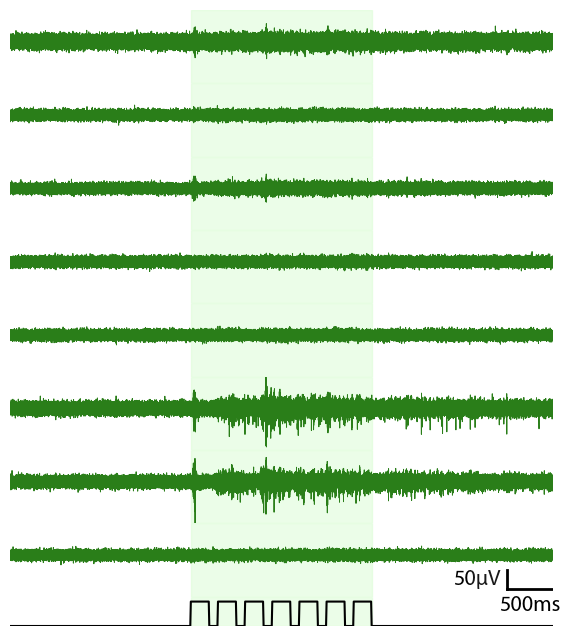

In [ ]:
# Charger les données du fichier brut
dat_file = dat_file_path  # Chemin vers votre fichier .dat
data = np.fromfile(dat_file, dtype=np.float32)  # Charger les données brutes

channel_map = np.load(gui_fold + "/channel_map.npy").reshape(-1, 8)
print("Mapping de l'électrode:", channel_map)

n_shanks, channels_per_shank = channel_map.shape  # Dimensions du mapping
n_channels = n_shanks * channels_per_shank  # Nombre total de canaux

assert data.size % n_channels == 0, "Le nombre de canaux ne correspond pas aux données chargées."

# Paramètres
sampling_rate = 30000  # Fréquence d'échantillonnage

# Reshape des données
data_reshaped = data.reshape((-1, n_channels))

# Réorganiser les canaux selon le mapping
mapped_indices = channel_map.flatten()
data_mapped = data_reshaped[:, mapped_indices]

# Sélection d'un shank spécifique
shank_id = 0  
shank_channels = channel_map[shank_id]  
data_shank = data_mapped[:, shank_channels]  

for i in range(n_stims):
    # Calcul des bornes pour chaque période en fonction du stimulus
    stim_start = t_stim_start[2]
    stim_end = stim_start + 2
    # stim_end = t_stim_end [0]

# Définir la période d'affichage
stim_duration = stim_end - stim_start

start_time = stim_start - stim_duration
end_time = stim_end + stim_duration

start_sample = int(start_time * sampling_rate)
end_sample = int(end_time * sampling_rate)

# Extraire les données pour cette plage
data_to_plot = data_shank[start_sample:end_sample, :]
time = np.arange(start_sample, end_sample) / sampling_rate  

# Inverser l'ordre pour affichage correct
shank_channels_reversed = shank_channels[::-1]  
data_to_plot_reversed = data_to_plot[:, ::-1]  

# Calculer les limites de l'axe Y
y_max_tac = np.max(data_to_plot_reversed)
y_min_tac = np.min(data_to_plot_reversed)

y_max_rounded = np.ceil(y_max_tac / 10) * 10
y_min_rounded = np.floor(y_min_tac / 10) * 10

print(f"min : {y_min_tac}, max : {y_max_tac}")
print(f"Valeur minimale arrondie: {y_min_rounded}, Valeur maximale arrondie: {y_max_rounded}")


# === Création des subplots ===
fig, axs = plt.subplots(nrows=channels_per_shank + 1, ncols=1, figsize=(7, 1 * channels_per_shank), gridspec_kw={'height_ratios': [1] * channels_per_shank + [0.4]})

# Tracer les signaux des électrodes
for i in range(channels_per_shank):
    real_channel = shank_channels_reversed[i]  
    axs[i].plot(time, data_to_plot_reversed[:, i], color="#2a7e19", linewidth=0.7, alpha=1)
    axs[i].axis('off')
    axs[i].axvspan(stim_start, stim_end, color='#d9fdd2', alpha=0.5, label='Tactile stim', zorder=0)
    axs[i].set_xlim(start_time, end_time)
    axs[i].set_ylim(y_min_tac, y_max_tac)



# === Tracer les pulses tactiles en dernier subplot ===
time_series = np.linspace(start_time, end_time, 1000)
pulse_series = np.zeros_like(time_series)

pulse_width = 0.2  
pulse_gap = 0.1    
num_pulses = 7     

pulse_starts = np.linspace(stim_start, stim_start + (num_pulses - 1) * (pulse_width + pulse_gap), num_pulses)

for pulse_start in pulse_starts:
    pulse_end = pulse_start + pulse_width
    pulse_indices = np.where((time_series >= pulse_start) & (time_series < pulse_end))[0]
    pulse_series[pulse_indices] = 1  

axs[-1].plot(time_series, pulse_series, color='k', linewidth=1.5)
axs[-1].axvspan(stim_start, stim_end, color='#d9fdd2', alpha=0.5, label='Tactile stim', zorder=0)
axs[-1].set_xlim(start_time, end_time)
axs[-1].set_ylim(0, 1.2)
axs[-1].axis('off')


# === boîte de légende en bas à droite du dernier subplot ===
# Choisir le subplot 7 (indice 6, car les indices commencent à 0)
shank_id = 7  # On veut placer la boîte dans le subplot 7

# Positionner la boîte en bas à droite du subplot 7
origin_x = end_time - 0.5  # Position en X (temps)
origin_y = y_min_tac + (y_max_tac - y_min_tac) * 0.1  # Position en Y (amplitude)

# Ajouter une boîte blanche pour améliorer la visibilité
legend_box = patches.FancyBboxPatch((origin_x - 0.2, origin_y - 10), 1.2, 60, 
                                    boxstyle="round,pad=0.2", edgecolor='white', 
                                    facecolor='white', alpha=0.1, lw=0.5, zorder=10)
axs[shank_id].add_patch(legend_box)  # Ajouter la boîte de légende dans le subplot 7

# Ajouter l’échelle de temps (barre horizontale)
time_x_end = origin_x + 0.5  # Longueur = 1 seconde
axs[shank_id].plot([origin_x, time_x_end], [origin_y, origin_y], color='black', linewidth=2, zorder=11)
axs[shank_id].text((origin_x + time_x_end) / 2, origin_y - 17, "500ms", fontsize=16, ha='center', va='top')

# Ajouter l’échelle d’amplitude (barre verticale)
amp_y_end = origin_y + 50  # Hauteur = 50 µV
axs[shank_id].plot([origin_x, origin_x], [origin_y, amp_y_end], color='black', linewidth=2, zorder=11)
axs[shank_id].text(origin_x - 0.6, (origin_y + amp_y_end) / 2, "50µV", fontsize=16, ha='left', va='center')

# Ajuster l'espacement des subplots sans les décaler
fig.subplots_adjust(hspace=0.001)

# Sauvegarder la figure
plt.savefig(os.path.join(saving_dir, '1B_WT_tac_cont_raw_traces.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, '1B_WT_tac_cont_raw_traces.svg'), format='svg', dpi=300)

plt.show()

#

### Fig 1.Bbis - Example LFP rec for tactile stim one shank

In [4]:
# Data file path
data_path = "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/Converter_circus"
sel_folder = "2024.02.06"
sel_rec = 'allego_00__uid0206-13-23-30'

full_folder = os.path.join(data_path, sel_folder, sel_rec)
print (f'path for full folder : {full_folder}')

if os.path.exists(full_folder):
    print(f"Le dossier existe: {full_folder}")
else:
    print(f"Le dossier n'existe pas: {full_folder}")


# .dat file Path
dat_file = sel_rec + '_spy.dat'
# print(dat_file)

dat_file_path = os.path.join (full_folder,dat_file)
print (f'\npath for .dat : {dat_file_path}')


# Zarr and lfp data path
zarr_path = 'U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/Analysis_stef'
zarr_folder = sel_folder
zarr_file = sel_rec 
# zarr_file = sel_rec + '_spy'
zarr_folder_path = os.path.join(zarr_path, zarr_folder, zarr_file)

    # Vérification que le chemin est correct
print(f"\nzarr file path : {zarr_folder_path}")

    # Ouvrir les fichiers zarr
raw_data = zarr.open(os.path.join(zarr_folder_path, 'raw', 'dataset.zarr'), mode="r")
ephys_res = zarr.open(os.path.join(zarr_folder_path, 'processed', 'ephys.zarr'), mode="r")

# Affichage de quelques informations sur les datasets
print(f"Contenu de raw_data : {list(raw_data.keys())}")
print(f"Contenu de ephys_res : {list(ephys_res.keys())}")


# Circus sorting path
sorting_fold = os.path.join(full_folder, sel_rec +'_spy')
sorting_path = Path(sorting_fold)
print (f'\npath for circus sorting : {sorting_path}')

gui_fold = os.path.join(sorting_fold, sel_rec + '_spy.GUI')
gui_path = Path(gui_fold)
print (f'\npath for circus-GUI : {gui_fold}')


# cluster_info.tsv file path
clusinfo_path = os.path.join(gui_fold, 'cluster_info.tsv')

# Vérifier si le fichier existe avant de tenter de le lire
if os.path.exists(clusinfo_path):
    print ('')
    clusinfo_df = pd.read_csv(clusinfo_path, sep='\t')  # Fichier tabulé
else:
    raise FileNotFoundError(f"Fichier introuvable : {clusinfo_path}")


path for full folder : U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/Converter_circus\2024.02.06\allego_00__uid0206-13-23-30
Le dossier existe: U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/Converter_circus\2024.02.06\allego_00__uid0206-13-23-30

path for .dat : U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/Converter_circus\2024.02.06\allego_00__uid0206-13-23-30\allego_00__uid0206-13-23-30_spy.dat

zarr file path : U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/Analysis_stef\2024.02.06\allego_00__uid0206-13-23-30
Contenu de raw_data : ['adcs', 'channels']
Contenu de ephys_res : ['down_fact', 'lfps', 'sample_rate']

path for circus sorting : U:\PhD\Experimentation\Electrophysiology\S1_recordings_Analysis\Converter_circus\2024.02.06\allego_00__uid0206-13-23-30\allego_00__uid0206-13-23-30_spy

path for circus-GUI : U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/Converter_circus\2024.02.06\allego_00__ui

In [5]:
### POUR TTL NEGATIF ###

####### Mapping #######

mapping = np.load(gui_fold + "/channel_map.npy").reshape(-1, 8)

####### LFPs + ADCs from zarr #######

lfps = ephys_res["lfps/channels/1"][:]
lfps -= np.median(lfps, axis=0)
adcs = ephys_res["lfps/adcs/1"][:]
stim_present = (adcs[0,:] < 0).astype(int)
t_lfps = ephys_res["lfps/timestamps/1"][:]

srate_acq = (t_lfps.size - 1) / (t_lfps[-1] - t_lfps[0])
print(f"\nFréquence d'échantillonnage : {srate_acq} Hz")

np.sum(adcs[0,:]<0) > t_lfps.size/2


####### Sampling rate for acquisition #######

f_sample_raw = 30000.0


####### Création du dataset pour spiketimes et amplitudes #######

dataset = {}
merged = list(sorting_path.glob("*.result.hdf5"))

if len(merged) != 1:
    logging.warning("Several or none .result.hdf5 file detected. Aborting!")
else:
    with h5py.File(merged[0], "r") as spike_in:
        dataset["spiketimes"] = {}
        dataset["amplitudes"] = {}  # Ajout pour les amplitudes

        for temp in spike_in["spiketimes"].items():
            # Extraction des données de spiketimes
            spiketimes_data = temp[1][:] / f_sample_raw
            dataset["spiketimes"][temp[0]] = spiketimes_data

            # Vérification de la présence d'amplitudes
            if "amplitudes" in spike_in:
                amplitudes_data = spike_in["amplitudes"][temp[0]][:]
                dataset["amplitudes"][temp[0]] = amplitudes_data
            else:
                logging.warning(f"No amplitudes found for {temp[0]}")


####### Selection des neurones valides #######

# Filtrer les neurones valides
valid_df = clusinfo_df.loc[clusinfo_df['group'].isin(['good', 'mua'])]

# Liste des neurones valides (pas les index, mais les valeurs)
valid_all = valid_df['cluster_id'].tolist()

# Récupérer les neurones valides par shank
n_shanks = 4
valid_per_sh = {}
for i_sh in range(n_shanks):
    valid_inds = valid_df.loc[valid_df['sh'] == float(i_sh), 'cluster_id'].tolist()
    valid_per_sh[f'sh#{i_sh}'] = valid_inds


# On transforme les indices dans valid_all en clés correspondant aux sous-clés 'temp_x'
valid_keys = [f'temp_{i}' for i in valid_all]


####### Here we infer the stim #######

if TYPE_CHECKING:
    # Type annotations
    Abool = npt.NDArray[np.bool_]
    Afloat = npt.NDArray[np.float64]
    Aint = npt.NDArray[np.int_]


# def infer_stim_times(stim_signal, tstamp, th_dur=15.0):
def infer_stim_times(stim_signal, tstamp, th_dur=2.5):


    """Infer stimulus start/stop times from the stimulus signal ttl.

    Args:
        stim_signal (Afloat): stimulus signal ttl .
        t_lfps (Afloat): tstemp of the lfp.
        th_dur (float): duration threshold (in seconds) to infer valid times

    Returns:
        tuple(Afloat): stimulus start times, stimulus end times.

    """

    tactile = True
    if tactile:
        ind_start = 0
    else:
        ind_start = 1 
    up_inds = np.where(np.diff(stim_signal) > 0.5)[0][ind_start:] # stim signal goes up, excluding recording start
    down_inds = np.where(np.diff(stim_signal) < -0.5)[0][ind_start:] # stim signal goes down, excluding recording start

    t_up = tstamp[up_inds]
    t_down = tstamp[down_inds]
    
    valid_up = np.diff(t_up) > th_dur # this is 15. seconds 
    valid_up = np.concatenate(([True], valid_up)) # the first up is always valid
    
    valid_down = np.diff(t_down) > th_dur
    valid_down = np.concatenate((valid_down, [True])) # the last down is always valid
    
    t_stim_start = t_up[valid_up]
    t_stim_end = t_down[valid_down]

    return t_stim_start, t_stim_end

valid_temp_profile = np.max(adcs[0,:]) > 0.5
# valid_temp_profile = np.max(adcs[0,:]) < 0.5

if valid_temp_profile:
    therm_stim = 10. * adcs[0,:]

t_stim_start, t_stim_end = infer_stim_times(stim_signal=stim_present,tstamp=t_lfps)

n_stims = t_stim_start.size


Fréquence d'échantillonnage : 1000.0 Hz


Mapping de l'électrode: [[11  4  8 13 10  6  9 12]
 [14  1  2  3 15  5  0  7]
 [30 22 28 29 26 27 24 31]
 [25 16 20 18 23 17 19 21]]
min : -709.4509570013417, max : 246.80854614676298
Valeur minimale arrondie: -710.0, Valeur maximale arrondie: 250.0


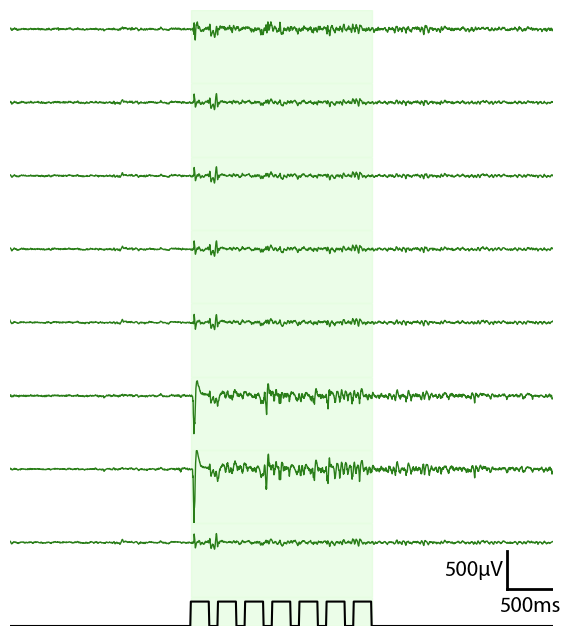

In [19]:
# Charger les données du fichier brut
dat_file = dat_file_path  # Chemin vers votre fichier .dat
data = np.fromfile(dat_file, dtype=np.float32)  # Charger les données brutes

channel_map = np.load(gui_fold + "/channel_map.npy").reshape(-1, 8)
print("Mapping de l'électrode:", channel_map)

n_shanks, channels_per_shank = channel_map.shape  # Dimensions du mapping
n_channels = n_shanks * channels_per_shank  # Nombre total de canaux

assert data.size % n_channels == 0, "Le nombre de canaux ne correspond pas aux données chargées."

# Paramètres
sampling_rate = 30000  # Fréquence d'échantillonnage

# Reshape des données
data_reshaped = data.reshape((-1, n_channels))

# Réorganiser les canaux selon le mapping
mapped_indices = channel_map.flatten()
data_mapped = data_reshaped[:, mapped_indices]

# Sélection d'un shank spécifique
shank_id = 0  
shank_channels = channel_map[shank_id]  
data_shank = data_mapped[:, shank_channels]  

for i in range(n_stims):
    # Calcul des bornes pour chaque période en fonction du stimulus
    stim_start = t_stim_start[2]
    stim_end = stim_start + 2
    # stim_end = t_stim_end [0]

# Définir la période d'affichage
stim_duration = stim_end - stim_start

start_time = stim_start - stim_duration
end_time = stim_end + stim_duration

start_sample = int(start_time * sampling_rate)
end_sample = int(end_time * sampling_rate)

# Extraire les données pour cette plage
data_to_plot = data_shank[start_sample:end_sample, :]
time = np.arange(start_sample, end_sample) / sampling_rate  

# Inverser l'ordre pour affichage correct
shank_channels_reversed = shank_channels[::-1]  
data_to_plot_reversed = data_to_plot[:, ::-1]  

# Fonction pour appliquer un filtre passe-bas
def lowpass_filter(data, cutoff=200, fs=30000, order=4):
    nyquist = 0.5 * fs  # Fréquence de Nyquist
    normal_cutoff = cutoff / nyquist
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return filtfilt(b, a, data, axis=0)

# Appliquer le filtrage passe-bas Butterworth
data_filtered = lowpass_filter(data_to_plot_reversed)

# Appliquer le filtre Savitzky-Golay (fenêtre = 101, polynôme = 3)
data_filtered_savgol = savgol_filter(data_filtered, window_length=101, polyorder=3, axis=0)


# Calculer les limites de l'axe Y
y_max_tac = np.max(data_filtered_savgol)
y_min_tac = np.min(data_filtered_savgol)

y_max_rounded = np.ceil(y_max_tac / 10) * 10
y_min_rounded = np.floor(y_min_tac / 10) * 10

print(f"min : {y_min_tac}, max : {y_max_tac}")
print(f"Valeur minimale arrondie: {y_min_rounded}, Valeur maximale arrondie: {y_max_rounded}")


# === Création des subplots ===
fig, axs = plt.subplots(nrows=channels_per_shank + 1, ncols=1, figsize=(7, 1 * channels_per_shank), gridspec_kw={'height_ratios': [1] * channels_per_shank + [0.4]})

# Tracer les signaux des électrodes
for i in range(channels_per_shank):
    real_channel = shank_channels_reversed[i]  
    axs[i].plot(time, data_filtered_savgol[:, i], color="#2a7e19", linewidth=1)
    axs[i].axis('off')
    axs[i].axvspan(stim_start, stim_end, color='#d9fdd2', alpha=0.5, label='Tactile stim', zorder=0)
    axs[i].set_xlim(start_time, end_time)
    axs[i].set_ylim(y_min_rounded, y_max_rounded)



# === Tracer les pulses tactiles en dernier subplot ===
time_series = np.linspace(start_time, end_time, 1000)
pulse_series = np.zeros_like(time_series)

pulse_width = 0.2  
pulse_gap = 0.1    
num_pulses = 7     

pulse_starts = np.linspace(stim_start, stim_start + (num_pulses - 1) * (pulse_width + pulse_gap), num_pulses)

for pulse_start in pulse_starts:
    pulse_end = pulse_start + pulse_width
    pulse_indices = np.where((time_series >= pulse_start) & (time_series < pulse_end))[0]
    pulse_series[pulse_indices] = 1  

axs[-1].plot(time_series, pulse_series, color='k', linewidth=1.5)
axs[-1].axvspan(stim_start, stim_end, color='#d9fdd2', alpha=0.5, label='Tactile stim', zorder=0)
axs[-1].set_xlim(start_time, end_time)
axs[-1].set_ylim(0, 1.2)
axs[-1].axis('off')


# === boîte de légende en bas à droite du dernier subplot ===
# Choisir le subplot 7 (indice 6, car les indices commencent à 0)
shank_id = 7  # On veut placer la boîte dans le subplot 7

# Positionner la boîte en bas à droite du subplot 7
origin_x = end_time - 0.5  # Position en X (temps)
origin_y = y_min_tac + (y_max_tac - y_min_tac) * 0.1  # Position en Y (amplitude)

# Ajouter une boîte blanche pour améliorer la visibilité
legend_box = patches.FancyBboxPatch((origin_x - 0.2, origin_y - 10), 1.2, 60, 
                                    boxstyle="round,pad=0.2", edgecolor='white', 
                                    facecolor='white', alpha=0.1, lw=0.5, zorder=10)
axs[shank_id].add_patch(legend_box)  # Ajouter la boîte de légende dans le subplot 7

# Ajouter l’échelle de temps (barre horizontale)
time_x_end = origin_x + 0.5  # Longueur = 1 seconde
axs[shank_id].plot([origin_x, time_x_end], [origin_y, origin_y], color='black', linewidth=2, zorder=11)
axs[shank_id].text((origin_x + time_x_end) / 2, origin_y - 100, "500ms", fontsize=16, ha='center', va='top')

# Ajouter l’échelle d’amplitude (barre verticale)
amp_y_end = origin_y + 500  # Hauteur = 50 µV
axs[shank_id].plot([origin_x, origin_x], [origin_y, amp_y_end], color='black', linewidth=2, zorder=11)
axs[shank_id].text(origin_x - 0.7, (origin_y + amp_y_end) / 2, "500µV", fontsize=16, ha='left', va='center')

# Ajuster l'espacement des subplots sans les décaler
fig.subplots_adjust(hspace=0.001)

# Sauvegarder la figure
plt.savefig(os.path.join(saving_dir, '1Bbis_WT_tac_cont_raw_traces.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, '1Bbis_WT_tac_cont_raw_traces.svg'), format='svg', dpi=300)

plt.show()

#

### Fig 1.C - Exemple raster for tactile stim one neuron (8 stim)

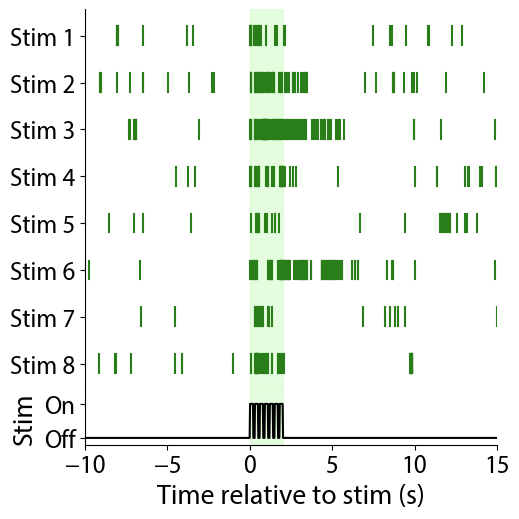

valid_key[4]: temp_14


In [47]:
# Paramètres
time_before_stim = 10  # 10 secondes avant le début du stimulus
time_after_stim = 15   # 15 secondes après le début du stimulus

# Sélectionner un valid_key
valid_key = valid_keys[4]  # Choisir un seul neurone

# Récupérer les spikes pour ce neurone spécifique
spikes = dataset['spiketimes'][valid_key]

# === Création des subplots ===
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(5, 5), sharex=True, gridspec_kw={'height_ratios': [7, 1]})

# Tracer les spikes pour chaque stimulus
for i in range(len(t_stim_start)):  # Pour chaque stimulus (de 1 à 8)
    stim_start = t_stim_start[i]
    stim_end = t_stim_end[i]

    # Définir la fenêtre d'intérêt autour du stimulus (10 secondes avant et après)
    window_start = stim_start - time_before_stim
    window_end = stim_end + time_after_stim

    # Sélectionner les spikes dans cette fenêtre et les aligner par rapport au début du stimulus
    selected_spikes = [spike - stim_start for spike in spikes if window_start <= spike <= window_end]

    # Tracer les spikes alignés pour ce stimulus
    for spike in selected_spikes:
        ax1.plot([spike, spike], [i + 0.2, i - 0.2], color='#2a7e19')  # Ligne verticale pour chaque spike

# Paramétrage du raster plot
ax1.set_ylabel('')  # Label de l'axe Y

# Inverser l'ordre des ticks de l'axe Y et l'axe Y
ax1.set_yticks(range(len(t_stim_start)-1, -1, -1))  # Inverser l'ordre des ticks
ax1.set_yticklabels([f'Stim {i+1}' for i in range(len(t_stim_start)-1, -1, -1)])  # Labels des stimuli inversés

# Limiter l'axe des x pour afficher la fenêtre autour du stimulus
ax1.set_xlim([-time_before_stim, time_after_stim])  # Afficher de -10s à +15s autour de chaque stimulus

# Inverser l'axe Y pour avoir Stim 1 en haut et Stim 8 en bas
ax1.invert_yaxis()  # Inverse l'axe Y

ax1.axvspan(0, 2, color='#d9fdd2', alpha=0.7, label='Tactile stim', zorder=0)

# Suppression des bordures superflues
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['bottom'].set_visible(False)
ax1.xaxis.set_visible(False)


# === Tracer les pulses tactiles en dernier subplot ===
time_series = np.linspace(-time_before_stim, time_after_stim, 1000)
pulse_series = np.zeros_like(time_series)

pulse_width = 0.2  # Durée de chaque pulsation
pulse_gap = 0.1    # Ecart entre chaque pulsation
num_pulses = 7     # Nombre de pulsations

# Placer les pulsations pour chaque stimulus
for i in range(len(t_stim_start)):  # Pour chaque stimulus
    stim_start = t_stim_start[i]

    # Calculer le temps de début des pulsations dans la fenêtre [0, 2s]
    pulse_starts = np.linspace(0, 2 - pulse_width, num_pulses)  # Les pulsations commencent à 0 et s'étendent sur 2 secondes

    # Ajouter chaque pulsation
    for pulse_start in pulse_starts:
        pulse_end = pulse_start + pulse_width

        # Ajouter les indices des pulsations dans la série de temps
        pulse_indices = np.where((time_series >= pulse_start) & (time_series < pulse_end))[0]
        pulse_series[pulse_indices] = 1

# Tracer les impulsions tactiles dans le second subplot
ax2.plot(time_series, pulse_series, color='k', linewidth=1.5)

ax2.axvspan(0, 2, color='#d9fdd2', alpha=0.7, label='Tactile stim', zorder=0)

ax2.set_xlim(-time_before_stim, time_after_stim)
ax2.set_xlabel('Time relative to stim (s)')
ax2.set_ylabel('Stim')
ax2.set_yticks([0, 1])
ax2.set_ylim(-0.2, 1.4)  # Ajuster pour rendre les pulses visibles
ax2.set_yticklabels(['Off', 'On'])


# Suppression des bordures superflues
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# Ajustements finaux
plt.tight_layout(pad=0.001, h_pad=0.001)

# Sauvegarder la figure
plt.savefig(os.path.join(saving_dir, '1C_WT_tac_cont_raster.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, '1C_WT_tac_cont_raster.svg'), format='svg', dpi=300)

plt.show()

print(f'valid_key[4]: {valid_keys[4]}')



#

### Fig 1.D - Tactile response rate contra vs ipsi

n (Cont) = 9
n (Ipsi) = 9
Wilcoxon test result: statistic = 1.0000, p-value = 0.0078


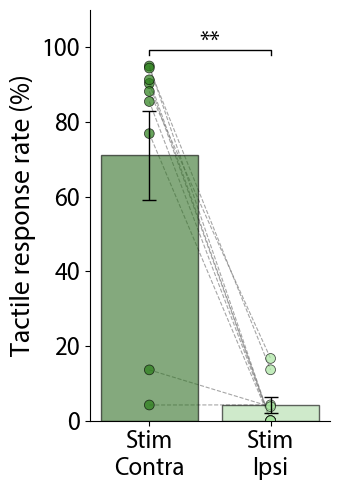


WT_tac_cont : mean = 71.05 ± 11.91
WT_tac_ipsi : mean = 4.25 ± 2.15

contra: n_cluster : 566
ipsi: n_cluster : 401
        directory                    file_name  response_percentage
0      2024.01.31   allego_2__uid0131-14-02-00            71.428571
1      2024.01.31   allego_4__uid0131-14-50-27            82.352941
2      2024.02.06   allego_0__uid0206-13-23-30            90.000000
3      2024.02.06   allego_9__uid0206-15-27-25           100.000000
4      2024.02.23   allego_0__uid0223-14-32-31             4.347826
5      2024.02.23   allego_1__uid0223-14-47-14             4.054054
6      2024.03.01   allego_0__uid0301-15-26-22            85.483871
7      2024.03.05   allego_1__uid0305-14-26-56           100.000000
8      2024.03.05   allego_2__uid0305-14-38-40            80.645161
9      2024.04.03   allego_7__uid0403-16-27-36           100.000000
10     2024.04.03   allego_8__uid0403-16-36-36            98.275862
11     2024.05.22   allego_0__uid0522-15-18-41            11.428571


In [4]:
# Charger les fichiers
WT_tac_cont_path = "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/cluster_response_rate/Tac_Wcont_WT_resp_rate.xlsx"
df_WT_tac_cont = pd.read_excel(WT_tac_cont_path)

WT_tac_ipsi_path = "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/cluster_response_rate/Tac_Wipsi_WT_resp_rate.xlsx"
df_WT_tac_ipsi = pd.read_excel(WT_tac_ipsi_path)

# Calcul du pourcentage de '1' dans la colonne 'response' pour chaque combinaison de 'directory' et 'file_name'
def calculate_response_percentage(df):
    # Grouper par 'directory' et 'file_name' et calculer le pourcentage de 1 dans la colonne 'response'
    response_percentage = df.groupby(['directory', 'file_name'])['response'].agg(
        lambda x: (x.sum() / len(x)) * 100
    ).reset_index()
    
    # Renommer la colonne pour plus de clarté
    response_percentage.rename(columns={'response': 'response_percentage'}, inplace=True)
    
    return response_percentage

# Appliquer la fonction sur chaque DataFrame
response_percentage_WT_tac_cont = calculate_response_percentage(df_WT_tac_cont)
response_percentage_WT_tac_ipsi = calculate_response_percentage(df_WT_tac_ipsi)

# Extraire les 'directory' présents dans les deux DataFrames
directories_cont = response_percentage_WT_tac_cont['directory']
directories_ipsi = response_percentage_WT_tac_ipsi['directory']

# Trouver les 'directory' communs aux deux DataFrames
common_directories = set(directories_cont).intersection(set(directories_ipsi))

# Filtrer les DataFrames pour ne conserver que les 'directory' communs
filtered_cont = response_percentage_WT_tac_cont[response_percentage_WT_tac_cont['directory'].isin(common_directories)]
filtered_ipsi = response_percentage_WT_tac_ipsi[response_percentage_WT_tac_ipsi['directory'].isin(common_directories)]

# Calculer la moyenne des pourcentages de réponse pour chaque 'directory' commun
average_response_percentage_cont = filtered_cont.groupby('directory')['response_percentage'].mean().reset_index()
average_response_percentage_ipsi = filtered_ipsi.groupby('directory')['response_percentage'].mean().reset_index()

# Créer une nouvelle colonne 'group' pour identifier chaque DataFrame
average_response_percentage_cont['group'] = 'Cont'
average_response_percentage_ipsi['group'] = 'Ipsi'

# Fusionner les deux DataFrames en un seul
combined_df = pd.concat([average_response_percentage_cont, average_response_percentage_ipsi])

# Calculer la SEM pour chaque groupe
combined_df['sem'] = combined_df.groupby('group')['response_percentage'].transform(sem)

# Calculer n (le nombre d'observations pour chaque groupe)
n_cont = len(average_response_percentage_cont)
n_ipsi = len(average_response_percentage_ipsi)

# Effectuer le test de Wilcoxon pour comparer les groupes 'Cont' et 'Ipsi'
stat, p_value = wilcoxon(average_response_percentage_cont['response_percentage'], 
                         average_response_percentage_ipsi['response_percentage'])

# Afficher les résultats avec n et p-value
print(f"n (Cont) = {n_cont}")
print(f"n (Ipsi) = {n_ipsi}")
print(f"Wilcoxon test result: statistic = {stat:.4f}, p-value = {p_value:.4f}")


# Couleurs
colors = {'Cont': '#2a7e19', 'Ipsi': '#A8E5A0'}
border_colors = 'k'

# Plot
plt.figure(figsize=(3.5, 5))

# Créer un barplot par groupe (moyenne des response_percentage par group) avec des couleurs personnalisées
sns.barplot(x='group', y='response_percentage', data=combined_df, 
            errorbar=None,  # Désactive les barres d'erreur
            hue='group', palette=colors, capsize=0.1, err_kws={'linewidth': 1}, alpha=0.6, edgecolor=border_colors)

# Ajouter des points de scatter pour chaque directory avec des couleurs personnalisées pour chaque groupe
sns.scatterplot(x='group', y='response_percentage', hue='group', data=combined_df, 
                palette=colors, s=50, legend=None, marker='o', edgecolor=border_colors, alpha=0.7)

# Ajouter les lignes de connexion entre les points de 'Cont' et 'Ipsi' pour chaque 'directory'
for directory in common_directories:
    cont_value = average_response_percentage_cont[average_response_percentage_cont['directory'] == directory]['response_percentage'].values[0]
    ipsi_value = average_response_percentage_ipsi[average_response_percentage_ipsi['directory'] == directory]['response_percentage'].values[0]
    
    # Tracer une ligne entre les points 'Cont' et 'Ipsi' pour le même 'directory'
    plt.plot(['Cont', 'Ipsi'], [cont_value, ipsi_value], color='grey', linestyle='--', linewidth=0.8, alpha=0.7, zorder=0)

# Ajouter les barres d'erreur (SEM)
for i, group in enumerate(combined_df['group'].unique()):
    group_data = combined_df[combined_df['group'] == group]
    plt.errorbar(x=[i], y=group_data['response_percentage'].mean(), yerr=group_data['sem'].mean(),
                 fmt='none', color=border_colors, capsize=5, elinewidth=1)


# Fonction pour ajouter une barre de significativité
def add_Wilcox_sig_bar(x1, x2, y, p_val, height_offset=1.2, fontsize=18):
    if p_val < 0.001:
        significance = "***"
    elif p_val < 0.01:
        significance = "**"
    elif p_val < 0.05:
        significance = "*"
    else:
        return

    plt.plot([x1, x1, x2, x2], [y, y + height_offset, y + height_offset, y], lw=1, color='black')
    plt.text((x1 + x2) * 0.5, y , significance, ha='center', va='bottom', color='black', fontsize=fontsize)

# Ajouter la barre de significativité si p < 0.05
y_max = max(combined_df['response_percentage']) + 0.02  # Ajustement vertical
if p_value < 0.05:
    add_Wilcox_sig_bar(0, 1, y_max + 3, p_value)


# Ajouter le titre et les labels
plt.xlabel('')
plt.ylabel('Tactile response rate (%)')
xtick_labels = ['Stim\nContra', 'Stim\nIpsi']  # Les nouveaux labels pour les xticks
plt.xticks(ticks=[0, 1], labels=xtick_labels)
plt.ylim(0, 110)


# Suppression des bordures superflues
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Afficher le graphique
plt.tight_layout()

# # Sauvegarder la figure
# plt.savefig(os.path.join(saving_dir, '1D_WT_tac_cont_ipsi_resp_rate.png'), format='png', dpi=300)
# plt.savefig(os.path.join(saving_dir, '1D_WT_tac_cont_ipsi_resp_rate.svg'), format='svg', dpi=300)

plt.show()


############################    Metrics   ############################ 

# Calculer la moyenne et SEM pour 'WT_tac_cont'
mean_cont = average_response_percentage_cont['response_percentage'].mean()
sem_cont = sem(average_response_percentage_cont['response_percentage'])

# Calculer la moyenne et SEM pour 'WT_tac_ipsi'
mean_ipsi = average_response_percentage_ipsi['response_percentage'].mean()
sem_ipsi = sem(average_response_percentage_ipsi['response_percentage'])

# Afficher les résultats
print(f"\nWT_tac_cont : mean = {mean_cont:.2f} ± {sem_cont:.2f}")
print(f"WT_tac_ipsi : mean = {mean_ipsi:.2f} ± {sem_ipsi:.2f}")

# Calculer nombre cluster par conditions
n_cluster_tac_cont = len(df_WT_tac_cont)
n_cluster_tac_ipsi = len(df_WT_tac_ipsi)

print(f"\ncontra: n_cluster : {n_cluster_tac_cont}")
print(f"ipsi: n_cluster : {n_cluster_tac_ipsi}")

print (response_percentage_WT_tac_cont)


### Fig 1.D_BIS - Cluster/Contingence - Tactile response rate contra vs ipsi

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



Table de contingence (nombre d'occurences de 0 et 1 par groupe) :
response    0    1
Tac_Cont  236  330
Tac_Ipsi  389   12

Test chi2 de contingence entre groupes : chi2 = 311.715, p = 9.237e-70, dof = 1
=> Différence significative entre groupes

Tests post-hoc (test exact de Fisher) avec correction de Bonferroni :
Tac_Cont vs Tac_Ipsi : p = 7.988e-84, p corrigé = 7.988e-84 -> SIGNIFICATIF


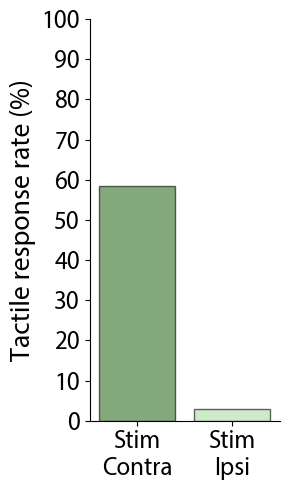


Métriques des réponses par groupe :
Tac_Cont : Moyenne = 0.58, Nombre de clusters = 566, Pourcentage de réponse = 58.3%
Tac_Ipsi : Moyenne = 0.03, Nombre de clusters = 401, Pourcentage de réponse = 3.0%


In [4]:
# Chemins fichiers
file_paths = {
    "Tac_Cont": "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/cluster_response_rate/Tac_Wcont_WT_resp_rate.xlsx",
    "Tac_Ipsi": "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/cluster_response_rate/Tac_Wipsi_WT_resp_rate.xlsx"
}


# Chargement des données
dfs = {}
for key, path in file_paths.items():
    if os.path.exists(path):
        dfs[key] = pd.read_excel(path)
    else:
        print(f"⚠️ Fichier non trouvé : {path}")


# Calcul pourcentages réponse/non-réponse
group_counts = {}
for key, df in dfs.items():
    counts = df['response'].value_counts(normalize=True) * 100
    group_counts[key] = {
        'No Response (0)': counts.get(0, 0),
        'Response (1)': counts.get(1, 0)
    }


# DataFrame pour plot
contingency_df = pd.DataFrame(group_counts).T.reset_index().rename(columns={'index': 'group'})
contingency_melted = contingency_df.melt(id_vars='group', var_name='Response Type', value_name='Percentage')
contingency_melted_response_only = contingency_melted[contingency_melted['Response Type'] == 'Response (1)']


# Couleurs personnalisées
response_colors = {
    'Tac_Cont': '#2a7e19',
    'Tac_Ipsi': '#A8E5A0'
}

border_colors = 'k'

# Plot barplot
plt.figure(figsize=(3, 5))
ax = sns.barplot(
    data=contingency_melted_response_only,
    x='group', y='Percentage', hue='group',
    palette=response_colors,
    edgecolor=border_colors,
    alpha=0.6, errorbar=None
)

# Table de contingence brute
contingency_table = pd.DataFrame({
    key: dfs[key]['response'].value_counts() for key in dfs.keys()
}).fillna(0).astype(int).T

print("\nTable de contingence (nombre d'occurences de 0 et 1 par groupe) :")
print(contingency_table)

# Test global chi2
chi2, p, dof, expected = chi2_contingency(contingency_table.values)
print(f"\nTest chi2 de contingence entre groupes : chi2 = {chi2:.3f}, p = {p:.4g}, dof = {dof}")
if p < 0.05:
    print("=> Différence significative entre groupes")
else:
    print("=> Pas de différence significative entre groupes")

# Tests post-hoc (Fisher exact test)
groups = contingency_table.index.tolist()
results = []

for g1, g2 in combinations(groups, 2):
    table = contingency_table.loc[[g1, g2], [0, 1]].values
    oddsratio, pvalue = fisher_exact(table)
    results.append({'Group1': g1, 'Group2': g2, 'pvalue': pvalue})

# Correction Bonferroni
num_tests = len(results)
for res in results:
    res['pvalue_corrected'] = min(res['pvalue'] * num_tests, 1.0)

print("\nTests post-hoc (test exact de Fisher) avec correction de Bonferroni :")
for res in results:
    signif = "SIGNIFICATIF" if res['pvalue_corrected'] < 0.05 else "non significatif"
    print(f"{res['Group1']} vs {res['Group2']} : p = {res['pvalue']:.4g}, p corrigé = {res['pvalue_corrected']:.4g} -> {signif}")


# # Annoter les significativités sur le plot
# def add_contingence_sig_bar(ax, x1, x2, y, p_val, height_offset=1, fontsize=18):
#     significance = ""
#     if p_val < 0.001:
#         significance = "***"
#     elif p_val < 0.01:
#         significance = "**"
#     elif p_val < 0.05:
#         significance = "*"
#     if significance:
#         ax.plot([x1, x1, x2, x2], [y, y + height_offset, y + height_offset, y], lw=1, color='black')
#         ax.text((x1 + x2) * 0.5, y - 0.05 , significance,
#                 ha='center', va='bottom', color='black', fontsize=fontsize)

# positions = {g: i for i, g in enumerate(contingency_df['group'])}
# y_offset = contingency_melted_response_only['Percentage'].max() + 5
# spacing_between_bars = 0.8

# for res in results:
#     if res['pvalue_corrected'] < 0.05:
#         x1 = positions[res['Group1']]
#         x2 = positions[res['Group2']]
#         add_contingence_sig_bar(ax, x1, x2, y_offset, res['pvalue_corrected'])
#         y_offset += spacing_between_bars

# Labels
plt.xlabel('')
plt.ylabel('Tactile response rate (%)')
plt.xticks(ticks=[0, 1], labels=['Stim\nContra', 'Stim\nIpsi'])
plt.yticks(range(0, 101, 10))
plt.ylim(0, 100)

# Suppression bordures inutiles
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.legend().remove()
plt.tight_layout()

# Sauvegarder la figure
plt.savefig(os.path.join(saving_dir, '1D_BIS_WT_tac_cont_ipsi_resp_rate_cluster_contingence.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, '1D_BIS_WT_tac_cont_ipsi_resp_rate_cluster_contingence.svg'), format='svg', dpi=300)

plt.show()


############################ Metrics ############################

print("\nMétriques des réponses par groupe :")
for key, df in dfs.items():
    mean_response = df['response'].mean()  # moyenne des 0 et 1 = taux de réponse en fraction
    n_clusters = len(df)
    response_percentage = mean_response * 100
    print(f"{key} : Moyenne = {mean_response:.2f}, Nombre de clusters = {n_clusters}, Pourcentage de réponse = {response_percentage:.1f}%")



#

### Fig 1.E - SDF_mean tactile contra WT

Friedman test results:
          Source     W  ddof1     Q     p-unc
Friedman  period  0.79      2  15.8  0.000371
Effet global de period: Significatif (p-unc = 0.0004)

Post-hoc Dunn test with Bonferroni correction:
           Baseline      Stim  Post_stim
Baseline   1.000000  0.007518   0.345907
Stim       0.007518  1.000000   0.000013
Post_stim  0.345907  0.000013   1.000000


c:\Users\zayan\Anaconda\envs\analysis\lib\site-packages\scikit_posthocs\_posthocs.py:371: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  x_lens = x.groupby(_group_col)[_val_col].count()
c:\Users\zayan\Anaconda\envs\analysis\lib\site-packages\scikit_posthocs\_posthocs.py:374: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  x_ranks_avg = x.groupby(_group_col)["ranks"].mean()


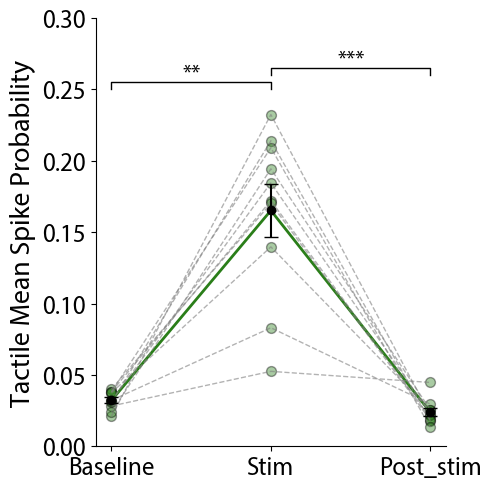

      period  mean_sdf   sem_sdf  N_animal
0   Baseline  0.032142  0.002031        10
1       Stim  0.165173  0.018324        10
2  Post_stim  0.023850  0.002733        10

       period  n_cluster
0   Baseline        566
1  Post_stim        566
2       Stim        566


In [4]:
# Charger le fichier
file_path = "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/mean_sdf_period_cluster/split_files/Tac_Wcont_WT_grouped.xlsx"
df = pd.read_excel(file_path)

# Définir l'ordre des périodes
period_order = ['Baseline', 'Stim', 'Post_stim']

# Calculer la moyenne de 'sdf' en groupant par 'directory' et 'period'
df_grouped = df.groupby(['directory', 'period'])['sdf'].mean().reset_index()

# Assurez-vous que les périodes sont dans l'ordre souhaité
df_grouped['period'] = pd.Categorical(df_grouped['period'], categories=period_order, ordered=True)

# Trier les données par période
df_grouped = df_grouped.sort_values('period')

# Calculer la moyenne et SEM pour chaque 'period'
mean_sdf = df_grouped.groupby('period', observed=False)['sdf'].mean()
sem_sdf = df_grouped.groupby('period', observed=False)['sdf'].sem()

# Test de Friedman
friedman_results = pg.friedman(data=df_grouped, dv='sdf', within='period', subject='directory')
print("Friedman test results:")
print(friedman_results)

# Vérifier la significativité
effect_significance = "Significatif" if friedman_results['p-unc'].iloc[0] < 0.05 else "Non significatif"
print(f"Effet global de period: {effect_significance} (p-unc = {friedman_results['p-unc'].iloc[0]:.4f})")


# Test de Dunn post-hoc avec correction de Bonferroni
if friedman_results['p-unc'].iloc[0] < 0.05 :
    posthoc_results = sp.posthoc_dunn(df_grouped, val_col='sdf', group_col='period', p_adjust='bonferroni')
    posthoc_results.index = period_order
    posthoc_results.columns = period_order
    print("\nPost-hoc Dunn test with Bonferroni correction:")
    print(posthoc_results)

# Créer le plot
plt.figure(figsize=(5, 5))
colors = '#2a7e19'
border_colors = 'k'

# Ajouter les points individuels
plt.scatter(df_grouped['period'], df_grouped['sdf'], color=colors, edgecolor=border_colors, linewidth=1, alpha=0.4, marker='o', s=50, zorder=1)

# Ajouter les lignes de connexion entre périodes
for directory in df_grouped['directory'].unique():
    subset = df_grouped[df_grouped['directory'] == directory]
    plt.plot(subset['period'], subset['sdf'], color='grey', linestyle='--', alpha=0.6, lw=1)

# Ajouter les points de la moyenne
plt.scatter(mean_sdf.index, mean_sdf.values, color='black', s=20, label='Mean', zorder=10)
plt.errorbar(mean_sdf.index, mean_sdf.values, yerr=sem_sdf.values, fmt='o', color='black', capsize=5, zorder=2)
plt.plot(mean_sdf.index, mean_sdf.values, color=colors, linestyle='-', linewidth=2, zorder=1)

# Ajouter les barres de significativité
def add_sig_bar(x1, x2, y, p_val, height_offset=0.005, fontsize=16):
    significance = ""
    if p_val < 0.001:
        significance = "***"
    elif p_val < 0.01:
        significance = "**"
    elif p_val < 0.05:
        significance = "*"
    
    if significance:
        plt.plot([x1, x1, x2, x2], [y, y + height_offset, y + height_offset, y], lw=1, color='black')
        plt.text((x1 + x2) * 0.5, y + height_offset, significance, ha='center', va='bottom', color='black', fontsize=fontsize)

positions = {'Baseline': 0, 'Stim': 1, 'Post_stim': 2}
y_offset = 0.25  # Décalage vertical initial
spacing_between_bars = 0.01

if friedman_results['p-unc'].iloc[0] < 0.05 :
    for i, p1 in enumerate(period_order):
        for j, p2 in enumerate(period_order):
            if i < j:
                p_val = posthoc_results.loc[p1, p2]
                if p_val < 0.05:
                    add_sig_bar(positions[p1], positions[p2], y_offset, p_val)
                    y_offset += spacing_between_bars

plt.xlabel("")
plt.ylabel("Tactile Mean Spike Probability")
plt.xticks(ticks=np.arange(len(period_order)), labels=period_order)
plt.ylim(0,0.3)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()

# Sauvegarder la figure
plt.savefig(os.path.join(saving_dir, '1E_SDF_WT_tac_contra_period.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, '1E_SDF_WT_tac_contra_period.svg'), format='svg', dpi=300)

plt.show()


############################    Metrics   ############################ 

summary_table = df_grouped.groupby('period', observed=False).agg(
    mean_sdf=('sdf', 'mean'),
    sem_sdf=('sdf', 'sem'),
    N_animal=('sdf', 'size'),
).reset_index()
print(summary_table)

summary_table2 = df.groupby('period', observed=False).agg(
    n_cluster=('sdf', 'size')
).reset_index()
print("\n", summary_table2)


### Fig 1.E_BIS - Clusters - SDF_mean tactile contra WT

Period Baseline: p = 0.0000 (Non normal)
Period Stim: p = 0.0000 (Non normal)
Period Post_stim: p = 0.0000 (Non normal)

📊 Résultats du test de Friedman :
          Source         W  ddof1           Q          p-unc
Friedman  period  0.467783      2  529.530035  1.032794e-115

Effet global de 'period' : Significatif (p = 0.0000)

🧪 Post-hoc Dunn avec correction Bonferroni :
                Baseline           Stim      Post_stim
Baseline    1.000000e+00  2.560190e-122   2.948224e-02
Stim       2.560190e-122   1.000000e+00  3.099513e-150
Post_stim   2.948224e-02  3.099513e-150   1.000000e+00


c:\Users\zayan\Anaconda\envs\analysis\lib\site-packages\scikit_posthocs\_posthocs.py:371: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  x_lens = x.groupby(_group_col)[_val_col].count()
c:\Users\zayan\Anaconda\envs\analysis\lib\site-packages\scikit_posthocs\_posthocs.py:374: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  x_ranks_avg = x.groupby(_group_col)["ranks"].mean()


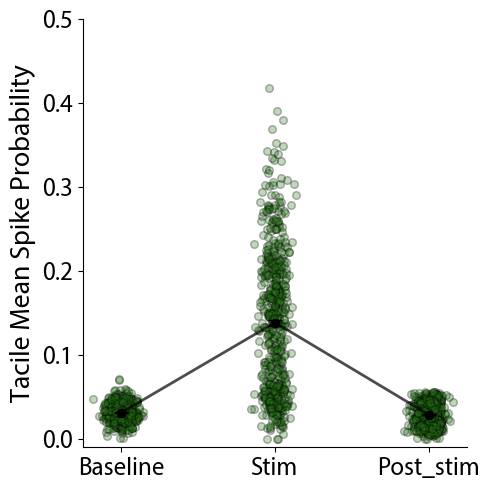


📈 Tableau récapitulatif par période :
      period  mean_sdf   sem_sdf  N_neuron_unique
0   Baseline  0.031180  0.000438              566
1       Stim  0.138547  0.003576              566
2  Post_stim  0.028700  0.000570              566


In [5]:
#  Charger le fichier Excel
file_path = "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/mean_sdf_period_cluster/split_files/Tac_Wcont_WT_grouped.xlsx"
df = pd.read_excel(file_path)

# Définir l'ordre des périodes
period_order = ['Baseline', 'Stim', 'Post_stim']
df['period'] = pd.Categorical(df['period'], categories=period_order, ordered=True)

# Regrouper par neurone unique et période pour s'assurer d'une entrée unique
df_unique = df.groupby(['directory', 'file_name', 'neuron_id', 'period'], as_index=False, observed=True).mean(numeric_only=True)

# Calculer la moyenne et SEM globales par période
mean_sem = df_unique.groupby('period', observed=True)['sdf'].agg(['mean', 'sem']).reindex(period_order)

# 1. Nettoyage des données
df_unique_clean = df_unique.dropna(subset=['sdf'])

# 2. Créer une colonne 'subject' pour identifier chaque neurone
df_unique_clean['subject'] = df_unique_clean['directory'] + '_' + df_unique_clean['file_name'] + '_' + df_unique_clean['neuron_id'].astype(str)


for period in df_unique_clean['period'].unique():
    subset = df_unique_clean[df_unique_clean['period'] == period]
    stat, p = shapiro(subset['sdf'])
    print(f"Period {period}: p = {p:.4f} ({'Non normal' if p < 0.05 else 'Normal'})")


# ---------- 📊 TEST DE FRIEDMAN ----------
# # 1. Nettoyage des données
# df_unique_clean = df_unique.dropna(subset=['sdf'])

# # 2. Créer une colonne 'subject' pour identifier chaque neurone
# df_unique_clean['subject'] = df_unique_clean['directory'] + '_' + df_unique_clean['file_name'] + '_' + df_unique_clean['neuron_id'].astype(str)

# 3. S'assurer que les périodes sont bien catégorisées et ordonnées
period_order = ['Baseline', 'Stim', 'Post_stim']
df_unique_clean['period'] = pd.Categorical(df_unique_clean['period'], categories=period_order, ordered=True)

# 4. Garder seulement les sujets ayant des valeurs pour toutes les périodes (Friedman exige mesures répétées complètes)
complete_subjects = df_unique_clean.groupby('subject')['period'].nunique() == len(period_order)
df_friedman_cool_cluster = df_unique_clean[df_unique_clean['subject'].isin(complete_subjects[complete_subjects].index)]

# 5. Appliquer le test de Friedman (format long)
friedman_results_cool_cluster = pg.friedman(data=df_friedman_cool_cluster, dv='sdf', within='period', subject='subject')
print("\n📊 Résultats du test de Friedman :")
print(friedman_results_cool_cluster)

# 6. Vérifier significativité
pval_cool_cluster = friedman_results_cool_cluster['p-unc'].iloc[0]
effect_significance = "Significatif" if pval_cool_cluster < 0.05 else "Non significatif"
print(f"\nEffet global de 'period' : {effect_significance} (p = {pval_cool_cluster:.4f})")

# 7. Si significatif, faire un post-hoc de Dunn
if pval_cool_cluster < 0.05:
    print("\n🧪 Post-hoc Dunn avec correction Bonferroni :")
    posthoc_results_cool_cluster = sp.posthoc_dunn(df_friedman_cool_cluster, val_col='sdf', group_col='period', p_adjust='bonferroni')
    posthoc_results_cool_cluster = posthoc_results_cool_cluster.loc[period_order, period_order]
    print(posthoc_results_cool_cluster)


# Créer le plot
plt.figure(figsize=(5, 5))
colors = '#2a7e19'
border_colors = 'k'

# Appliquer un jitter sur l'axe x
x_jitter = df_unique['period'].cat.codes + np.random.normal(0, 0.05, size=len(df_unique))

# Puis plot avec jitter
plt.scatter(x_jitter, df_unique['sdf'],
            color=colors, edgecolor=border_colors,
            linewidth=1, alpha=0.3, marker='o', s=30, zorder=0)

# Ajouter les moyennes ± SEM
plt.errorbar(mean_sem.index, mean_sem['mean'], yerr=mean_sem['sem'],
             fmt='o', color='black', capsize=5, label='Mean ± SEM', zorder=2)
plt.plot(mean_sem.index, mean_sem['mean'],
         color='k', alpha=0.7, linestyle='-', linewidth=2, zorder=1)

# # Ajouter les barres de significativité
# def add_sig_bar(x1, x2, y, p_val, height_offset=0.005, fontsize=18):
#     significance = ""
#     if p_val < 0.001:
#         significance = "***"
#     elif p_val < 0.01:
#         significance = "**"
#     elif p_val < 0.05:
#         significance = "*"
    
#     if significance:
#         plt.plot([x1, x1, x2, x2], [y, y + height_offset, y + height_offset, y], lw=1, color='black')
#         plt.text((x1 + x2) * 0.5, y - height_offset , significance, ha='center', va='bottom', color='black', fontsize=fontsize)

# positions = {'Baseline': 0, 'Stim': 1, 'Post_stim': 2}
# y_offset = 0.43  # Décalage vertical initial
# spacing_between_bars = 0.03

# if friedman_results_cool_cluster['p-unc'].iloc[0] < 0.05 :
#     for i, p1 in enumerate(period_order):
#         for j, p2 in enumerate(period_order):
#             if i < j:
#                 p_val = posthoc_results_cool_cluster.loc[p1, p2]
#                 if p_val < 0.05:
#                     add_sig_bar(positions[p1], positions[p2], y_offset, p_val)
#                     y_offset += spacing_between_bars



plt.xlabel("")
plt.ylabel("Tacile Mean Spike Probability")
plt.xticks(ticks=np.arange(len(period_order)), labels=period_order)
plt.ylim(-0.01,0.5)
plt.xlim(-0.25, len(period_order) - 0.75)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()


# Sauvegarder la figure
plt.savefig(os.path.join(saving_dir, '1E_Bis_SDF_WT_tac_contra_period_cluster.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, '1E_Bis_SDF_WT_tac_contra_period_cluster.svg'), format='svg', dpi=300)

plt.show()


############################    📊 Résumé par période   ############################

summary_table = df_friedman_cool_cluster.groupby('period', observed=True).agg(
    mean_sdf=('sdf', 'mean'),
    sem_sdf=('sdf', 'sem'),
    N_neuron_unique=('subject', 'nunique')
).reset_index()

print("\n📈 Tableau récapitulatif par période :")
print(summary_table)


#

### Fig 1.F - WT tactile contra vs ipsi sdf for TS


Test de Wilcoxon : Statistique=0.0, p-value=0.00390625, n=9


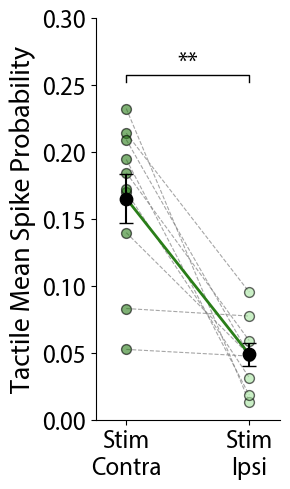

Moyenne et SEM pour 'Cont':
Groupe: Cont, Mean: 0.165173 ± SEM: 0.018324
Groupe: Ipsi, Mean: 0.048768 ± SEM: 0.008794

 contra: n_cluster : 566
ipsi: n_cluster : 401


In [14]:
# Charger les fichiers
WT_tac_cont_path = "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/mean_sdf_period_cluster/split_files/Tac_Wcont_WT_grouped.xlsx"
df_WT_tac_cont = pd.read_excel(WT_tac_cont_path)

WT_tac_ipsi_path = "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/mean_sdf_period_cluster/split_files/Tac_Wipsi_WT_grouped.xlsx"
df_WT_tac_ipsi = pd.read_excel(WT_tac_ipsi_path)

# Filtrer pour obtenir uniquement les données où la période est 'Stim'
df_WT_tac_cont_ts = df_WT_tac_cont[df_WT_tac_cont['period'] == 'Stim']
df_WT_tac_ipsi_ts = df_WT_tac_ipsi[df_WT_tac_ipsi['period'] == 'Stim']

# Calculer la moyenne de 'sdf' en groupant par 'directory'
df_WT_tac_cont_grouped = df_WT_tac_cont_ts.groupby('directory')['sdf'].mean().reset_index()
df_WT_tac_ipsi_grouped = df_WT_tac_ipsi_ts.groupby('directory')['sdf'].mean().reset_index()

# Ajouter une colonne pour différencier les groupes
df_WT_tac_cont_grouped['group'] = 'Cont'
df_WT_tac_ipsi_grouped['group'] = 'Ipsi'

# Fusionner les données pour analyse statistique
df_merged = pd.merge(df_WT_tac_cont_grouped, df_WT_tac_ipsi_grouped, on='directory', suffixes=('_cont', '_ipsi'))

# Test de Wilcoxon
n = len(df_merged)
stat, p_value = wilcoxon(df_merged['sdf_cont'], df_merged['sdf_ipsi'])

# Affichage des résultats statistiques
print(f"\nTest de Wilcoxon : Statistique={stat}, p-value={p_value}, n={n}")

# Fusionner pour le tracé
df_combined = pd.concat([df_WT_tac_cont_grouped, df_WT_tac_ipsi_grouped])

# Couleurs
colors = {'Cont': '#2a7e19', 'Ipsi': '#A8E5A0'}
border_colors = 'k'

# Création du plot
plt.figure(figsize=(3, 5))

# Ajouter les points individuels pour chaque 'directory'
for group in ['Cont', 'Ipsi']:
    subset = df_combined[df_combined['group'] == group]
    plt.scatter(subset['group'], subset['sdf'], color=colors[group], edgecolor=border_colors, linewidth=1, alpha=0.6, s=50, zorder=6)

# Ajouter les lignes entre les points appariés
for _, row in df_merged.iterrows():
    plt.plot(['Cont', 'Ipsi'], [row['sdf_cont'], row['sdf_ipsi']], color='grey', linestyle='--', linewidth=0.8, alpha=0.7, zorder=0)

# Calcul des moyennes et SEM
mean_sdf = df_combined.groupby('group')['sdf'].mean()
sem_sdf = df_combined.groupby('group')['sdf'].sem()

# Ajouter les moyennes avec barres d'erreur
plt.scatter(mean_sdf.index, mean_sdf.values, color='black', s=80, label='Mean', zorder=10)
plt.errorbar(mean_sdf.index, mean_sdf.values, yerr=sem_sdf.values, fmt='o', color='black', capsize=5, zorder=8)

# Ajouter la ligne reliant les moyennes
plt.plot(mean_sdf.index, mean_sdf.values, color='#2a7e19', linestyle='-', linewidth=2, zorder=7)

# Fonction pour ajouter une barre de significativité
def add_Wilcox_sig_bar(x1, x2, y, p_val, height_offset=0.005, fontsize=18):
    if p_val < 0.001:
        significance = "***"
    elif p_val < 0.01:
        significance = "**"
    elif p_val < 0.05:
        significance = "*"
    else:
        return

    plt.plot([x1, x1, x2, x2], [y, y + height_offset, y + height_offset, y], lw=1, color='black')
    plt.text((x1 + x2) * 0.5, y + height_offset, significance, ha='center', va='bottom', color='black', fontsize=fontsize)

# Ajouter la barre de significativité si p < 0.05
y_max = max(df_combined['sdf']) + 0.02  # Ajustement vertical
if p_value < 0.05:
    add_Wilcox_sig_bar(0, 1, y_max, p_value)

# Paramètres des axes
plt.xlabel("")
plt.ylabel("Tactile Mean Spike Probability")
plt.xticks([0, 1], ['Stim\nContra', 'Stim\nIpsi'])
plt.xlim(-0.25, 1.25)
plt.ylim(0,0.3)


# Suppression des bordures superflues
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Afficher le plot
plt.tight_layout()

# Sauvegarder la figure
plt.savefig(os.path.join(saving_dir, '1F_SDF_WT_TS_tac_cont_vs_ipsi.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, '1F_SDF_WT_TS_tac_cont_vs_ipsi.svg'), format='svg', dpi=300)


plt.show()

############################    Metrics   ############################ 

# Afficher les résultats
# Afficher les résultats des moyennes et SEM
print("Moyenne et SEM pour 'Cont':")
for group in ['Cont', 'Ipsi']:
    mean = mean_sdf[group]
    sem = sem_sdf[group]
    print(f"Groupe: {group}, Mean: {mean:.6f} ± SEM: {sem:.6f}")

# Calculer nombre cluster par conditions
n_cluster_tac_cont = len(df_WT_tac_cont_ts)
n_cluster_tac_ipsi = len(df_WT_tac_ipsi_ts)

print(f"\n contra: n_cluster : {n_cluster_tac_cont}")
print(f"ipsi: n_cluster : {n_cluster_tac_ipsi}")

### Fig 1.F_BIS - cluster - WT tactile contra vs ipsi sdf for TS


Test de Mann-Whitney : Statistique=191730.0000, p-value=0.0000, n_cont=566, n_ipsi=401


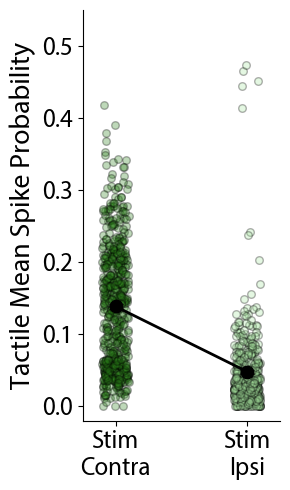

Moyenne et SEM pour chaque groupe :
Cont : 0.138547 ± 0.003576
Ipsi : 0.048105 ± 0.002914

Contra : n_cluster = 566
Ipsi   : n_cluster = 401


In [6]:
# Charger les fichiers
WT_tac_cont_path = "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/mean_sdf_period_cluster/split_files/Tac_Wcont_WT_grouped.xlsx"
df_WT_tac_cont = pd.read_excel(WT_tac_cont_path)

WT_tac_ipsi_path = "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/mean_sdf_period_cluster/split_files/Tac_Wipsi_WT_grouped.xlsx"
df_WT_tac_ipsi = pd.read_excel(WT_tac_ipsi_path)

# Filtrer pour obtenir uniquement les données où la période est 'Stim'
df_WT_tac_cont_ts = df_WT_tac_cont[df_WT_tac_cont['period'] == 'Stim']
df_WT_tac_ipsi_ts = df_WT_tac_ipsi[df_WT_tac_ipsi['period'] == 'Stim']

# Regrouper par neurone unique et période pour s'assurer d'une entrée unique
df_WT_tac_cont_ts_cluster = df_WT_tac_cont_ts.groupby(['directory', 'file_name', 'neuron_id', 'period'], as_index=False, observed=True).mean(numeric_only=True)
df_WT_tac_ipsi_ts_cluster = df_WT_tac_ipsi_ts.groupby(['directory', 'file_name', 'neuron_id', 'period'], as_index=False, observed=True).mean(numeric_only=True)

# Ajouter une colonne pour différencier les groupes
df_WT_tac_cont_ts_cluster['group'] = 'Cont'
df_WT_tac_ipsi_ts_cluster['group'] = 'Ipsi'


# Mann-Whitney test sur les deux groupes
sdf_tac_cont = df_WT_tac_cont_ts_cluster['sdf']
sdf_tac_ipsi = df_WT_tac_ipsi_ts_cluster['sdf']

stat_mannwhit, p_value_mannwhit = mannwhitneyu(sdf_tac_cont, sdf_tac_ipsi, alternative='two-sided')

print(f"\nTest de Mann-Whitney : Statistique={stat_mannwhit:.4f}, p-value={p_value_mannwhit:.4f}, n_cont={len(sdf_tac_cont)}, n_ipsi={len(sdf_tac_ipsi)}")


# Fusionner pour le tracé
df_combined_cluster = pd.concat([df_WT_tac_cont_ts_cluster, df_WT_tac_ipsi_ts_cluster])

# Couleurs
colors = {'Cont': '#2a7e19', 'Ipsi': '#A8E5A0'}
border_colors = 'k'

# Création du plot
plt.figure(figsize=(3, 5))

# Ajouter les points individuels avec léger jitter
group_mapping = {'Cont': 0, 'Ipsi': 1}
for group in ['Cont', 'Ipsi']:
    subset = df_combined_cluster[df_combined_cluster['group'] == group]
    x_vals = np.ones(len(subset)) * group_mapping[group]
    x_vals += np.random.uniform(-0.1, 0.1, size=len(subset))  # jitter horizontal
    plt.scatter(x_vals, subset['sdf'], color=colors[group], edgecolor=border_colors, linewidth=1, alpha=0.3, s=30, zorder=6)

# Calcul des moyennes et SEM
mean_sdf_cluster = df_combined_cluster.groupby('group')['sdf'].mean()
sem_sdf_cluster = df_combined_cluster.groupby('group')['sdf'].sem()


# Obtenir les positions numériques dans le même ordre que mean_sdf.index
x_pos = [group_mapping[group] for group in mean_sdf_cluster.index]

# Ajouter les moyennes avec barres d'erreur
plt.scatter(x_pos, mean_sdf_cluster.values, color='black', s=80, label='Mean', zorder=10)
plt.errorbar(x_pos, mean_sdf_cluster.values, yerr=sem_sdf_cluster.values, fmt='o', color='black', capsize=5, zorder=8)

# Ajouter la ligne reliant les moyennes
plt.plot(x_pos, mean_sdf_cluster.values, color='k', linestyle='-', linewidth=2, zorder=7)



# # Ajouter la barre de significativité
# def add_MannWhitney_sig_bar(x1, x2, y, p_value_mannwhit, height_offset=0.005, fontsize=18):
#     if p_value_mannwhit < 0.001:
#         significance = "***"
#     elif p_value_mannwhit < 0.01:
#         significance = "**"
#     elif p_value_mannwhit < 0.05:
#         significance = "*"
#     else:
#         return
#     plt.plot([x1, x1, x2, x2], [y, y + height_offset, y + height_offset, y], lw=1, color='black')
#     plt.text((x1 + x2) * 0.5, y + height_offset, significance, ha='center', va='bottom', color='black', fontsize=fontsize)

# # Ajouter si p < 0.05
# y_max = max(df_combined_cluster['sdf']) + 0.02
# if p_value_mannwhit < 0.05:
#     add_MannWhitney_sig_bar(0, 1, y_max, p_value_mannwhit)

# Mise en forme
plt.xlabel("")
plt.ylabel("Tactile Mean Spike Probability")
plt.xticks([0, 1], ['Stim\nContra', 'Stim\nIpsi'])
plt.xlim(-0.25, 1.25)
plt.ylim(-0.02, 0.55)

# Nettoyer les bords
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

# Sauvegarder la figure
plt.savefig(os.path.join(saving_dir, '1F_BIS_SDF_WT_TS_tac_cont_vs_ipsi_cluster.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, '1F_BIS_SDF_WT_TS_tac_cont_vs_ipsi_cluster.svg'), format='svg', dpi=300)


plt.show()


############################    Metrics   ############################ 
print("Moyenne et SEM pour chaque groupe :")
for group in ['Cont', 'Ipsi']:
    mean = mean_sdf_cluster[group]
    sem = sem_sdf_cluster[group]
    print(f"{group} : {mean:.6f} ± {sem:.6f}")

# Nombre de clusters
n_cluster_tac_cont = len(df_WT_tac_cont_ts)
n_cluster_tac_ipsi = len(df_WT_tac_ipsi_ts)
print(f"\nContra : n_cluster = {n_cluster_tac_cont}")
print(f"Ipsi   : n_cluster = {n_cluster_tac_ipsi}")


#

# SDF Analysis by age

c:\Users\zayan\Anaconda\envs\analysis\lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\zayan\Anaconda\envs\analysis\lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


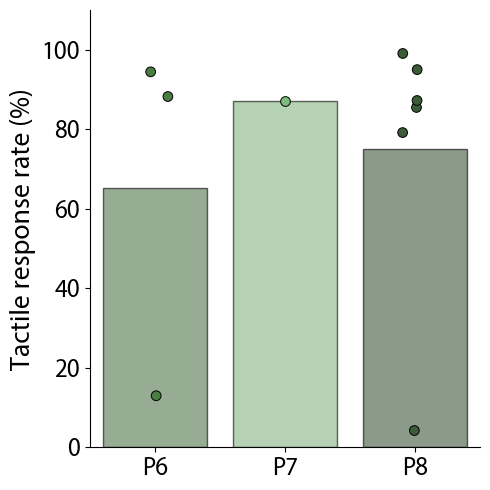

Kruskal-Wallis test: H = 0.036, p = 0.9820


C:\Users\zayan\AppData\Local\Temp\ipykernel_15112\2575410612.py:77: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = response_percentage.groupby('age')['response']


In [51]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import sem
from scipy.stats import kruskal


# Charger les données contra uniquement
WT_tac_cont_path = "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/cluster_response_rate/Tac_Wcont_WT_resp_rate.xlsx"
df_WT_tac_cont = pd.read_excel(WT_tac_cont_path)

# Calcul du pourcentage de réponse pour chaque directory
response_percentage = df_WT_tac_cont.groupby(['directory'])['response'].agg(
    lambda x: (x.sum() / len(x)) * 100
).reset_index()

# Ajouter l'âge depuis 'file_name' ou directement depuis df_WT_tac_cont
file_age_map = df_WT_tac_cont[['directory', 'age']].drop_duplicates()
response_percentage = response_percentage.merge(file_age_map, on='directory', how='left')

# Définir l'ordre des âges correct : P6, P7, P8
age_order = ['P6', 'P7', 'P8']
response_percentage['age'] = pd.Categorical(response_percentage['age'], categories=age_order, ordered=True)

# Calcul des moyennes et SEM par âge
mean_sem_by_age = response_percentage.groupby('age', observed=True)['response'].agg(['mean', sem]).reset_index()
mean_sem_by_age.rename(columns={'mean': 'response_mean', 'sem': 'response_sem'}, inplace=True)

# Couleurs personnalisées (modifiable à ton goût)
age_colors = {'P6': '#4a7c44', 'P7': '#7dbd7b', 'P8': '#3a5c36'}


# Création de la figure
plt.figure(figsize=(5, 5))

# Barplot (moyenne ± SEM)
sns.barplot(
    data=mean_sem_by_age, x='age', y='response_mean', hue='age',
    palette=age_colors, capsize=0.2, edgecolor='k', alpha=0.6,
    err_kws={'color': 'k', 'linewidth': 1.5},
    legend=False
)


# Ajouter les points individuels par directory
sns.stripplot(
    data=response_percentage, x='age', y='response', hue='age',
    palette=age_colors, s=7, jitter=True, dodge=False,
    edgecolor='k', linewidth=0.7,
    legend=False
)


# Personnalisation
plt.ylabel("Tactile response rate (%)")
plt.xlabel("")
plt.ylim(0, 110)

# Nettoyage des bordures
ax = plt.gca()
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.tight_layout()

# Sauvegarder la figure
plt.savefig(os.path.join(saving_dir, 'Age_response_rate_WT_tac.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, 'Age_response_rate_WT_tac.svg'), format='svg', dpi=300)

plt.show()



################# Stat Kruskal-Wallis #################

# Extraire les groupes de données pour chaque âge
grouped = response_percentage.groupby('age')['response']
P6_data = grouped.get_group('P6').dropna()
P7_data = grouped.get_group('P7').dropna()
P8_data = grouped.get_group('P8').dropna()

# Effectuer le test de Kruskal-Wallis
stat, p_value = kruskal(P6_data, P7_data, P8_data)

# Afficher le résultat
print(f"Kruskal-Wallis test: H = {stat:.3f}, p = {p_value:.4f}")


#

C:\Users\zayan\AppData\Local\Temp\ipykernel_56184\2688528057.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_grouped = df.groupby(['directory', 'period', 'age'])['sdf'].mean().reset_index()
c:\Users\zayan\Anaconda\envs\analysis\lib\site-packages\matplotlib\axes\_axes.py:1185: RuntimeWarning: All-NaN axis encountered
  miny = np.nanmin(masked_verts[..., 1])
c:\Users\zayan\Anaconda\envs\analysis\lib\site-packages\matplotlib\axes\_axes.py:1186: RuntimeWarning: All-NaN axis encountered
  maxy = np.nanmax(masked_verts[..., 1])


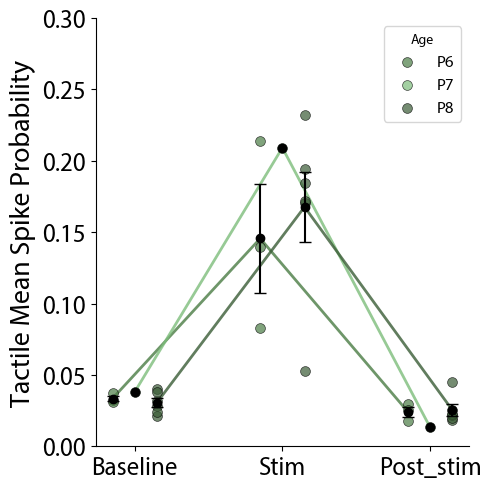


Résumé par période et âge :
      period age  mean_sdf   sem_sdf
0   Baseline  P6  0.033448  0.002065
1   Baseline  P7  0.038018       NaN
2   Baseline  P8  0.030510  0.003110
3       Stim  P6  0.145564  0.037919
4       Stim  P7  0.209119       NaN
5       Stim  P8  0.167653  0.024813
6  Post_stim  P6  0.024133  0.003434
7  Post_stim  P7  0.013334       NaN
8  Post_stim  P8  0.025462  0.003979

Nombre d'animaux uniques par âge :
P6 : 3
P7 : 1
P8 : 6


C:\Users\zayan\AppData\Local\Temp\ipykernel_56184\2688528057.py:120: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  n_animals_by_age = df[['directory', 'age']].drop_duplicates().groupby('age').size().to_dict()


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pingouin as pg
import scikit_posthocs as sp

# ------------------- CHARGEMENT DES DONNÉES ------------------- #

# Charger le fichier
file_path = "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/mean_sdf_period_cluster/split_files/Tac_Wcont_WT_grouped.xlsx"
df = pd.read_excel(file_path)

# Définir l'ordre des périodes et des âges
period_order = ['Baseline', 'Stim', 'Post_stim']
age_order = ['P6', 'P7', 'P8']

df['period'] = pd.Categorical(df['period'], categories=period_order, ordered=True)
df['age'] = pd.Categorical(df['age'], categories=age_order, ordered=True)

# Calculer la moyenne de sdf par directory et period
df_grouped = df.groupby(['directory', 'period', 'age'])['sdf'].mean().reset_index()

# Moyenne + SEM par combinaison période-âge (pour le graph)
mean_sem_by_age = df_grouped.groupby(['period', 'age'], observed=False).agg(
    mean_sdf=('sdf', 'mean'),
    sem_sdf=('sdf', 'sem')
).reset_index()

# ------------------- PLOT ------------------- #

# Définir les couleurs pour chaque âge
age_colors = {'P6': '#4a7c44', 'P7': '#7dbd7b', 'P8': '#3a5c36'}

# Position x des périodes
period_positions = {'Baseline': 0, 'Stim': 1, 'Post_stim': 2}
offset = 0.15  # pour espacer les âges

plt.figure(figsize=(5, 5))

# Tracer les points individuels avec décalage par âge
for i, period in enumerate(period_order):
    for j, age in enumerate(age_order):
        x = period_positions[period] + (j - 1) * offset  # -offset, 0, +offset
        subset = df_grouped[(df_grouped['period'] == period) & (df_grouped['age'] == age)]
        plt.scatter(
            [x] * len(subset),
            subset['sdf'],
            color=age_colors[age],
            edgecolor='k',
            linewidth=0.5,
            alpha=0.7,
            s=50,
            label=age if i == 0 else "",  # éviter doublons dans légende
            zorder=1
        )

# Ajouter les moyennes + SEM par période et âge
for i, period in enumerate(period_order):
    for j, age in enumerate(age_order):
        x = period_positions[period] + (j - 1) * offset
        row = mean_sem_by_age[(mean_sem_by_age['period'] == period) & (mean_sem_by_age['age'] == age)]
        if not row.empty:
            y = row['mean_sdf'].values[0]
            yerr = row['sem_sdf'].values[0]
            plt.errorbar(
                x,
                y,
                yerr=yerr,
                fmt='o',
                color='black',
                capsize=4,
                zorder=3
            )

# Ajouter les lignes de connexion entre les moyennes pour chaque âge
for j, age in enumerate(age_order):
    xs = []
    ys = []
    for period in period_order:
        row = mean_sem_by_age[(mean_sem_by_age['period'] == period) & (mean_sem_by_age['age'] == age)]
        if not row.empty:
            x = period_positions[period] + (j - 1) * offset
            y = row['mean_sdf'].values[0]
            xs.append(x)
            ys.append(y)
    if len(xs) == len(period_order):
        plt.plot(xs, ys, color=age_colors[age], linewidth=2, zorder=0, alpha=0.8)

# Définir les positions X pour les ticks
x_ticks = [period_positions[p] for p in period_order]
plt.xticks(ticks=x_ticks, labels=period_order)
plt.ylim(0, 0.3)
plt.ylabel("Tactile Mean Spike Probability")
plt.xlabel("")
plt.legend(title="Age")
plt.tight_layout()

# Nettoyage esthétique du graphe
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


# Sauvegarder la figure
plt.savefig(os.path.join(saving_dir, 'Age_SDF_WT_tac_period.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, 'Age_SDF_WT_tac_period.svg'), format='svg', dpi=300)


plt.show()

# ------------------- TABLEAUX DE SYNTHÈSE ------------------- #
# Moyenne/SEM/N par période et âge
summary_by_period_age = mean_sem_by_age.copy()

print("\nRésumé par période et âge :")
print(summary_by_period_age)

# Nombre d'animaux uniques par âge
n_animals_by_age = df[['directory', 'age']].drop_duplicates().groupby('age').size().to_dict()
summary_by_period_age['N_animals'] = summary_by_period_age['age'].map(n_animals_by_age)
print("\nNombre d'animaux uniques par âge :")
for age, n in n_animals_by_age.items():
    print(f"{age} : {n}")


SDF moyen par animal et par âge pendant la période 'Stim' :
age      directory        P6        P7        P8
0       2024.01.31       NaN       NaN  0.170179
1       2024.02.06       NaN       NaN  0.232357
2       2024.02.23       NaN       NaN  0.052489
3       2024.03.01       NaN       NaN  0.194337
4       2024.03.05       NaN       NaN  0.184448
5       2024.04.03       NaN       NaN  0.172111
6       2024.05.22  0.083023       NaN       NaN
7    2024.05.28_M1  0.213984       NaN       NaN
8    2024.05.28_M2  0.139686       NaN       NaN
9       2024.05.29       NaN  0.209119       NaN


c:\Users\zayan\Anaconda\envs\analysis\lib\site-packages\matplotlib\axes\_axes.py:1185: RuntimeWarning: All-NaN axis encountered
  miny = np.nanmin(masked_verts[..., 1])
c:\Users\zayan\Anaconda\envs\analysis\lib\site-packages\matplotlib\axes\_axes.py:1186: RuntimeWarning: All-NaN axis encountered
  maxy = np.nanmax(masked_verts[..., 1])


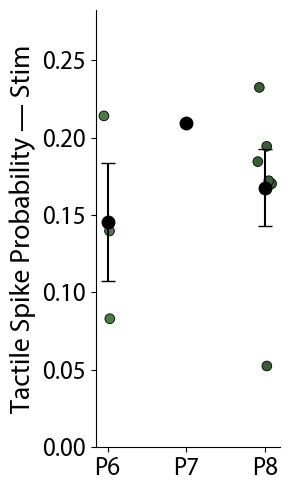

Résultat du test de Kruskal-Wallis :
Statistique = 0.909, p-value = 0.6347


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Filtrer les données à la période "Stim"
df_stim = df[df['period'] == 'Stim'].copy()

# Supprimer les doublons par directory pour éviter répétitions (si besoin)
df_stim_unique = df_stim.groupby(['directory', 'age'], observed=False)['sdf'].mean().reset_index()

# Réorganiser pour avoir les animaux en lignes et les âges en colonnes (facultatif, utile pour lecture ou stats)
sdf_pivot = df_stim_unique.pivot(index='directory', columns='age', values='sdf').reset_index()

# Affichage des résultats
print("SDF moyen par animal et par âge pendant la période 'Stim' :")
print(sdf_pivot)


# Calculer moyenne et SEM par âge
mean_sem = df_stim_unique.groupby('age', observed=False).agg(
    mean_sdf=('sdf', 'mean'),
    sem_sdf=('sdf', 'sem')
).reset_index()


# Couleurs par âge
age_colors = {'P6': '#4a7c44', 'P7': '#7dbd7b', 'P8': '#3a5c36'}

plt.figure(figsize=(3, 5))

# Points individuels par directory
sns.stripplot(
    data=df_stim_unique,
    x='age',
    y='sdf',
    hue='age',
    palette=age_colors,
    size=7,
    jitter=True,
    edgecolor='k',
    linewidth=0.6,
    zorder=1,
    order=['P6', 'P7', 'P8']  # <-- forcer l'ordre des âges
)

# Ajouter les moyennes ± SEM
for idx, row in mean_sem.iterrows():
    x = ['P6', 'P7', 'P8'].index(row['age'])  # <- Position x basée sur l’ordre
    y = row['mean_sdf']
    yerr = row['sem_sdf']
    plt.errorbar(
        x,
        y,
        yerr=yerr,
        fmt='o',
        color='black',
        capsize=5,
        markersize=9,
        zorder=2
    )


# Mise en forme
plt.ylabel("Tactile Spike Probability — Stim")
plt.xlabel("")
plt.ylim(0, df_stim_unique['sdf'].max() + 0.05)
sns.despine()
plt.tight_layout()


# Sauvegarder la figure
plt.savefig(os.path.join(saving_dir, 'Age_SDF_WT_tac_TS.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, 'Age_SDF_WT_tac_TS.svg'), format='svg', dpi=300)


plt.show()


import pingouin as pg
import scikit_posthocs as sp
import scipy.stats as stats

# Filtrer la période Stim et extraire les valeurs
df_stim = df[df['period'] == 'Stim'].copy()
df_stim_unique = df_stim.groupby(['directory', 'age'], observed=False)['sdf'].mean().reset_index()

# ------------------- Kruskal-Wallis ------------------- #
kruskal_result = stats.kruskal(
    *[df_stim_unique[df_stim_unique['age'] == age]['sdf'].dropna() for age in ['P6', 'P7', 'P8']]
)

print("Résultat du test de Kruskal-Wallis :")
print(f"Statistique = {kruskal_result.statistic:.3f}, p-value = {kruskal_result.pvalue:.4f}")


#

# SDF Analysis by Sex

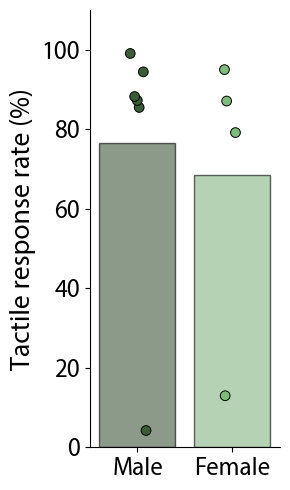

Résultat du test de Mann-Whitney U (M vs F) :
U = 15.000, p-value = 0.6095


C:\Users\zayan\AppData\Local\Temp\ipykernel_15112\4269723062.py:78: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = response_percentsex.groupby('sex')['response']


In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import sem

# Charger les données contra uniquement
WT_tac_cont_path = "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/cluster_response_rate/Tac_Wcont_WT_resp_rate.xlsx"
df_WT_tac_cont = pd.read_excel(WT_tac_cont_path)

# Calcul du pourcentsex de réponse pour chaque directory
response_percentsex = df_WT_tac_cont.groupby(['directory'])['response'].agg(
    lambda x: (x.sum() / len(x)) * 100
).reset_index()

# Ajouter l'âge depuis 'file_name' ou directement depuis df_WT_tac_cont
file_sex_map = df_WT_tac_cont[['directory', 'sex']].drop_duplicates()
response_percentsex = response_percentsex.merge(file_sex_map, on='directory', how='left')

# Définir l'ordre des âges correct : P6, P7, P8
sex_order = ['M', 'F']
response_percentsex['sex'] = pd.Categorical(response_percentsex['sex'], categories=sex_order, ordered=True)

# Calcul des moyennes et SEM par âge
mean_sem_by_sex = response_percentsex.groupby('sex', observed=True)['response'].agg(['mean', sem]).reset_index()
mean_sem_by_sex.rename(columns={'mean': 'response_mean', 'sem': 'response_sem'}, inplace=True)

# Couleurs personnalisées (modifiable à ton goût)
sex_colors = {'M': '#3a5c36', 'F': '#7dbd7b'}


# Création de la figure
plt.figure(figsize=(3, 5))

# Barplot (moyenne ± SEM)
sns.barplot(
    data=mean_sem_by_sex, x='sex', y='response_mean', hue='sex',
    palette=sex_colors, capsize=0.2, edgecolor='k', alpha=0.6,
    err_kws={'color': 'k', 'linewidth': 1.5},
    legend=False
)


# Ajouter les points individuels par directory
sns.stripplot(
    data=response_percentsex, x='sex', y='response', hue='sex',
    palette=sex_colors, s=7, jitter=True, dodge=False,
    edgecolor='k', linewidth=0.7,
    legend=False
)


# Personnalisation
plt.ylabel("Tactile response rate (%)")
plt.xlabel("")
plt.xticks([0, 1], ['Male', 'Female'])

plt.ylim(0, 110)

# Nettoysex des bordures
ax = plt.gca()
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.tight_layout()


# Sauvegarder la figure
plt.savefig(os.path.join(saving_dir, 'Sex_response_rate_WT_tac.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, 'Sex_response_rate_WT_tac.svg'), format='svg', dpi=300)

plt.show()



################# Stat Kruskal-Wallis #################

# Extraire les groupes de données pour chaque âge
grouped = response_percentsex.groupby('sex')['response']
M_data = grouped.get_group('M').dropna()
F_data = grouped.get_group('F').dropna()

mann_result = stats.mannwhitneyu(M_data, F_data, alternative='two-sided')
print("Résultat du test de Mann-Whitney U (M vs F) :")
print(f"U = {mann_result.statistic:.3f}, p-value = {mann_result.pvalue:.4f}")



#

C:\Users\zayan\AppData\Local\Temp\ipykernel_56184\84103384.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_grouped = df.groupby(['directory', 'period', 'sex'])['sdf'].mean().reset_index()


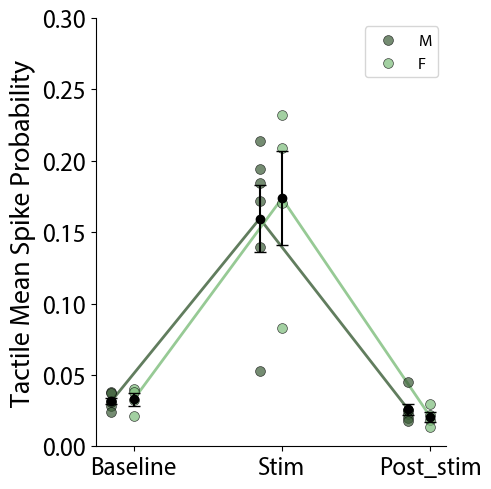


Résumé par période et sex :
      period sex  mean_sdf   sem_sdf
0   Baseline   M  0.031701  0.002232
1   Baseline   F  0.032804  0.004271
2       Stim   M  0.159509  0.023670
3       Stim   F  0.173670  0.032825
4  Post_stim   M  0.025928  0.003952
5  Post_stim   F  0.020734  0.003401

Nombre d'animaux uniques par sex :
M : 6
F : 4


C:\Users\zayan\AppData\Local\Temp\ipykernel_56184\84103384.py:121: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  n_animals_by_sex = df[['directory', 'sex']].drop_duplicates().groupby('sex').size().to_dict()


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pingouin as pg
import scikit_posthocs as sp

# ------------------- CHARGEMENT DES DONNÉES ------------------- #

# Charger le fichier
file_path = "U:/PhD/Experimentation/Electrophysiology/S1_recordings_Analysis/spyking_analysis/mean_sdf_period_cluster/split_files/Tac_Wcont_WT_grouped.xlsx"
df = pd.read_excel(file_path)

# Définir l'ordre des périodes et des sexs
period_order = ['Baseline', 'Stim', 'Post_stim']
sex_order = ['M', 'F']

df['period'] = pd.Categorical(df['period'], categories=period_order, ordered=True)
df['sex'] = pd.Categorical(df['sex'], categories=sex_order, ordered=True)

# Calculer la moyenne de sdf par directory et period
df_grouped = df.groupby(['directory', 'period', 'sex'])['sdf'].mean().reset_index()

# Moyenne + SEM par combinaison période-sex (pour le graph)
mean_sem_by_sex = df_grouped.groupby(['period', 'sex'], observed=False).agg(
    mean_sdf=('sdf', 'mean'),
    sem_sdf=('sdf', 'sem')
).reset_index()

# ------------------- PLOT ------------------- #

# Définir les couleurs pour chaque sex
sex_colors = {'M': '#3a5c36', 'F': '#7dbd7b'}

# Position x des périodes
period_positions = {'Baseline': 0, 'Stim': 1, 'Post_stim': 2}
offset = 0.15  # pour espacer les sexs

plt.figure(figsize=(5, 5))

# Tracer les points individuels avec décalsex par sex
for i, period in enumerate(period_order):
    for j, sex in enumerate(sex_order):
        x = period_positions[period] + (j - 1) * offset  # -offset, 0, +offset
        subset = df_grouped[(df_grouped['period'] == period) & (df_grouped['sex'] == sex)]
        plt.scatter(
            [x] * len(subset),
            subset['sdf'],
            color=sex_colors[sex],
            edgecolor='k',
            linewidth=0.5,
            alpha=0.7,
            s=50,
            label=sex if i == 0 else "",  # éviter doublons dans légende
            zorder=1
        )

# Ajouter les moyennes + SEM par période et sex
for i, period in enumerate(period_order):
    for j, sex in enumerate(sex_order):
        x = period_positions[period] + (j - 1) * offset
        row = mean_sem_by_sex[(mean_sem_by_sex['period'] == period) & (mean_sem_by_sex['sex'] == sex)]
        if not row.empty:
            y = row['mean_sdf'].values[0]
            yerr = row['sem_sdf'].values[0]
            plt.errorbar(
                x,
                y,
                yerr=yerr,
                fmt='o',
                color='black',
                capsize=4,
                zorder=3
            )

# Ajouter les lignes de connexion entre les moyennes pour chaque sex
for j, sex in enumerate(sex_order):
    xs = []
    ys = []
    for period in period_order:
        row = mean_sem_by_sex[(mean_sem_by_sex['period'] == period) & (mean_sem_by_sex['sex'] == sex)]
        if not row.empty:
            x = period_positions[period] + (j - 1) * offset
            y = row['mean_sdf'].values[0]
            xs.append(x)
            ys.append(y)
    if len(xs) == len(period_order):
        plt.plot(xs, ys, color=sex_colors[sex], linewidth=2, zorder=0, alpha=0.8)

# Définir les positions X pour les ticks
x_ticks = [period_positions[p] for p in period_order]
plt.xticks(ticks=x_ticks, labels=period_order)
plt.ylim(0, 0.3)
plt.ylabel("Tactile Mean Spike Probability")
plt.xlabel("")
plt.legend()
plt.tight_layout()

# Nettoysex esthétique du graphe
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


# Sauvegarder la figure
plt.savefig(os.path.join(saving_dir, 'Sex_SDF_WT_tac_period.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, 'Sex_SDF_WT_tac_period.svg'), format='svg', dpi=300)


plt.show()

# ------------------- TABLEAUX DE SYNTHÈSE ------------------- #

# Moyenne/SEM/N par période et sex
summary_by_period_sex = mean_sem_by_sex.copy()

print("\nRésumé par période et sex :")
print(summary_by_period_sex)

# Nombre d'animaux uniques par sex
n_animals_by_sex = df[['directory', 'sex']].drop_duplicates().groupby('sex').size().to_dict()
summary_by_period_sex['N_animals'] = summary_by_period_sex['sex'].map(n_animals_by_sex)
print("\nNombre d'animaux uniques par sex :")
for sex, n in n_animals_by_sex.items():
    print(f"{sex} : {n}")


SDF moyen par animal et par sexe pendant la période 'Stim' :
sex      directory         M         F
0       2024.01.31       NaN  0.170179
1       2024.02.06       NaN  0.232357
2       2024.02.23  0.052489       NaN
3       2024.03.01  0.194337       NaN
4       2024.03.05  0.184448       NaN
5       2024.04.03  0.172111       NaN
6       2024.05.22       NaN  0.083023
7    2024.05.28_M1  0.213984       NaN
8    2024.05.28_M2  0.139686       NaN
9       2024.05.29       NaN  0.209119


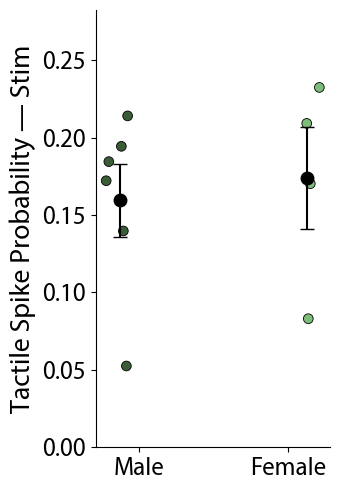

Résultat du test de Mann-Whitney U (M vs F) :
U = 10.000, p-value = 0.7619


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import scipy.stats as stats

# ---------------------- Filtrage et préparation ---------------------- #

# Filtrer les données à la période "Stim"
df_stim = df[df['period'] == 'Stim'].copy()

# Calcul du SDF moyen par animal (directory) et par sexe
df_stim_unique = df_stim.groupby(['directory', 'sex'], observed=False)['sdf'].mean().reset_index()

# Réorganiser pour affichage (facultatif)
sdf_pivot = df_stim_unique.pivot(index='directory', columns='sex', values='sdf').reset_index()
print("SDF moyen par animal et par sexe pendant la période 'Stim' :")
print(sdf_pivot)

# ---------------------- Plot avec points + moyennes/SEM ---------------------- #

# Moyenne et SEM par sexe
mean_sem = df_stim_unique.groupby('sex', observed=False).agg(
    mean_sdf=('sdf', 'mean'),
    sem_sdf=('sdf', 'sem')
).reset_index()

# Couleurs personnalisées
sex_colors = {'M': '#3a5c36', 'F': '#7dbd7b'}

plt.figure(figsize=(3.5, 5))

# Affichage des points (un par animal/directory)
sns.stripplot(
    data=df_stim_unique,
    x='sex',
    y='sdf',
    hue='sex',
    palette=sex_colors,
    size=7,
    jitter=True,
    edgecolor='k',
    linewidth=0.6,
    zorder=1
)

# Moyenne ± SEM
for i, row in mean_sem.iterrows():
    x = row['sex']
    y = row['mean_sdf']
    yerr = row['sem_sdf']
    plt.errorbar(
        x,
        y,
        yerr=yerr,
        fmt='o',
        color='black',
        capsize=5,
        markersize=9,
        zorder=2
    )

# Mise en forme du plot
plt.ylabel("Tactile Spike Probability — Stim")
plt.ylim(0, df_stim_unique['sdf'].max() + 0.05)
plt.xlabel("")
plt.xticks([0.1, 0.9], ['Male', 'Female'])
sns.despine()
plt.tight_layout()


# Sauvegarder la figure
plt.savefig(os.path.join(saving_dir, 'Sex_SDF_WT_tac_TS.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, 'Sex_SDF_WT_tac_TS.svg'), format='svg', dpi=300)

plt.show()

# ---------------------- Test statistique Mann-Whitney ---------------------- #

group_M = df_stim_unique[df_stim_unique['sex'] == 'M']['sdf'].dropna()
group_F = df_stim_unique[df_stim_unique['sex'] == 'F']['sdf'].dropna()


mann_result = stats.mannwhitneyu(group_M, group_F, alternative='two-sided')
print("Résultat du test de Mann-Whitney U (M vs F) :")
print(f"U = {mann_result.statistic:.3f}, p-value = {mann_result.pvalue:.4f}")



#

#

#

----

#

# pour filtre savgol de scipy (savgol_ 101,3)